# Goal
Analyze the export performance of semiconductor products (specifically integrated circuits) by destination country to identify high-value markets and trends using trade data.

# Data Loading

| Column                                                 | Description                                                                                         |
| ------------------------------------------------------ | --------------------------------------------------------------------------------------------------- |
| **typeCode**                                           | Type of dataset (e.g., trade data category, usually 'C' for commodity)                              |
| **freqCode**                                           | Frequency of the data (usually annual or monthly)                                                   |
| **refPeriodId**, **refYear**, **refMonth**, **period** | Time indicators — useful for time-series analysis                                                   |
| **reporterCode**, **reporterISO**, **reporterDesc**    | Country that is reporting the trade (e.g., Taiwan)                                                  |
| **flowCode**, **flowDesc**                             | Type of trade: Import or Export                                                                     |
| **partnerCode**, **partnerISO**, **partnerDesc**       | Trade partner (who you're buying from or selling to)                                                |
| **cmdCode**                                            | HS (Harmonized System) commodity code — identifies the product (e.g., 8542 for ICs)                 |
| **cmdDesc**                                            | Product description (e.g., “Electronic integrated circuits”)                                        |
| **qty**, **netWgt**, **grossWgt**                      | Quantity and weight of traded goods (may be True/False if not filled correctly)                     |
| **fobvalue**                                           | **Free On Board** value — cost of goods at point of export (good for export-focused value)          |
| **cifvalue**                                           | **Cost, Insurance, and Freight** — includes shipping/import costs (useful for import-side analysis) |
| **motCode**, **motDesc**                               | Mode of transport (e.g., sea, air)                                                                  |
| **customsCode**, **customsDesc**                       | Customs declaration info                                                                            |
| **qtyUnitCode**, **qtyUnitAbbr**                       | Units of measurement (e.g., kg, pieces)                                                             |
| **isReported**                                         | Whether the data is officially reported (vs. estimated)                                             |

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import platform
from pathlib import Path
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
pd.reset_option('display.max_rows')

In [2]:
base_path = Path("D:/Git_folder/Dibimbing---DSDA/Final Project Data Science/data_monthly")


if platform.system() == "Windows":
    base_path = Path("D:/Git_folder/Dibimbing---DSDA/Final Project Data Science/data_monthly")
else:
    base_path = Path("/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly")

file_names = [
    "TradeDataJan25.csv", "TradeDataFeb25.csv", "TradeDataMar25.csv", "TradeDataApr25.csv",
    "TradeDataMay25.csv", "TradeDataJan24.csv", "TradeDataFeb24.csv",
    "TradeDataMar24.csv", "TradeDataApr24.csv", "TradeDataMay24.csv", "TradeDataJune24.csv",
    "TradeDataJuly24.csv", "TradeDataAug24.csv", "TradeDataSep24.csv", "TradeDataOct24.csv",
    "TradeDataNov24.csv", "TradeDataDec24.csv", "TradeDataJan23.csv", "TradeDataFeb23.csv",
    "TradeDataMar23.csv", "TradeDataApr23.csv", "TradeDataMay23.csv", "TradeDataJune23.csv",
    "TradeDataJuly23.csv", "TradeDataAug23.csv", "TradeDataSep23.csv", "TradeDataOct23.csv",
    "TradeDataNov23.csv", "TradeDataDec23.csv", "TradeDataJan22.csv", "TradeDataFeb22.csv",
    "TradeDataMar22.csv", "TradeDataApr22.csv", "TradeDataMay22.csv", "TradeDataJune22.csv",
    "TradeDataJuly22.csv", "TradeDataAug22.csv", "TradeDataSep22.csv", "TradeDataOct22.csv",
    "TradeDataNov22.csv", "TradeDataDec22.csv", "TradeDataJan21.csv", "TradeDataFeb21.csv",
    "TradeDataMar21.csv", "TradeDataApr21.csv", "TradeDataMay21.csv", "TradeDataJune21.csv",
    "TradeDataJuly21.csv", "TradeDataAug21.csv", "TradeDataSep21.csv", "TradeDataOct21.csv",
    "TradeDataNov21.csv", "TradeDataDec21.csv", "TradeDataJan20.csv", "TradeDataFeb20.csv",
    "TradeDataMar20.csv", "TradeDataApr20.csv", "TradeDataMay20.csv", "TradeDataJune20.csv",
    "TradeDataJuly20.csv", "TradeDataAug20.csv", "TradeDataSep20.csv", "TradeDataOct20.csv",
    "TradeDataNov20.csv", "TradeDataDec20.csv"
]

files = [str(base_path / name) for name in file_names]


schema = pd.read_csv(files[0], dtype=str, encoding="latin1", low_memory=False).columns.tolist()

def read_and_fix(fp):
    df = pd.read_csv(fp, dtype=str, encoding="latin1", low_memory=False)
    df = df.reindex(columns=schema)


    mask = df["freqCode"].str.fullmatch(r"\d{8}", na=False)
    if mask.any():
        cols = df.columns.tolist()
        j = cols.index("freqCode")

        bad = df.loc[mask, cols].copy()
        bad.iloc[:, j+1:] = bad.iloc[:, j:-1].values
        bad.iloc[:, j] = "M"

        rpid = bad["refPeriodId"].str.extract(r"(\d{8})", expand=False)
        ok = rpid.notna()
        bad.loc[ok, "refYear"]  = rpid[ok].str.slice(0, 4)
        bad.loc[ok, "refMonth"] = rpid[ok].str.slice(4, 6).astype(int).astype(str)
        bad.loc[ok, "period"]   = (bad.loc[ok, "refYear"].astype(int)*100 + bad.loc[ok, "refMonth"].astype(int)).astype(str)

        df.loc[mask, cols] = bad.values

    return df

dfs = [read_and_fix(f) for f in files]
merged = pd.concat(dfs, ignore_index=True)

print(merged.iloc[0][["typeCode","freqCode","refPeriodId","refYear","refMonth","period"]])

#merged.to_csv("merged_fixed.csv", index=False, encoding="utf-8")

typeCode              M
freqCode              M
refPeriodId    20250101
refYear            2025
refMonth              1
period           202501
Name: 0, dtype: object


In [3]:
merged

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,0.033,0.033,0,false,true
6499996,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,25769533.042,25769533.042,0,false,true
6499997,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,9358.809,9358.809,0,false,true
6499998,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,181567.864,181567.864,0,false,true


In [4]:
df = merged
df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,0.033,0.033,0,false,true
6499996,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,25769533.042,25769533.042,0,false,true
6499997,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,9358.809,9358.809,0,false,true
6499998,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,181567.864,181567.864,0,false,true


# Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500000 entries, 0 to 6499999
Data columns (total 47 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   typeCode                  object
 1   freqCode                  object
 2   refPeriodId               object
 3   refYear                   object
 4   refMonth                  object
 5   period                    object
 6   reporterCode              object
 7   reporterISO               object
 8   reporterDesc              object
 9   flowCode                  object
 10  flowDesc                  object
 11  partnerCode               object
 12  partnerISO                object
 13  partnerDesc               object
 14  partner2Code              object
 15  partner2ISO               object
 16  partner2Desc              object
 17  classificationCode        object
 18  classificationSearchCode  object
 19  isOriginalClassification  object
 20  cmdCode                   object
 21  cmdDesc 

We have 47 tables, but not all of them is useful

In [6]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

typeCode: 1 unique values
freqCode: 1 unique values
refPeriodId: 65 unique values
refYear: 6 unique values
refMonth: 12 unique values
period: 65 unique values
reporterCode: 128 unique values
reporterISO: 128 unique values
reporterDesc: 128 unique values
flowCode: 2 unique values
flowDesc: 2 unique values
partnerCode: 247 unique values
partnerISO: 245 unique values
partnerDesc: 247 unique values
partner2Code: 243 unique values
partner2ISO: 243 unique values
partner2Desc: 243 unique values
classificationCode: 4 unique values
classificationSearchCode: 1 unique values
isOriginalClassification: 1 unique values
cmdCode: 2 unique values
cmdDesc: 2 unique values
aggrLevel: 2 unique values
isLeaf: 1 unique values
customsCode: 1 unique values
customsDesc: 1 unique values
mosCode: 1 unique values
motCode: 1 unique values
motDesc: 1 unique values
qtyUnitCode: 3 unique values
qtyUnitAbbr: 2 unique values
qty: 100350 unique values
isQtyEstimated: 2 unique values
altQtyUnitCode: 4 unique values
altQt

In [7]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print("-" * 40)

Column: typeCode
['M']
1
----------------------------------------
Column: freqCode
['M']
1
----------------------------------------
Column: refPeriodId
['20250101' '20250201' '20250301' '20250401' '20250501' '20240101'
 '20240201' '20240301' '20240401' '20240501' '20240601' '20240701'
 '20240801' '20240901' '20241001' '20241101' '20241201' '20230101'
 '20230201' '20230301' '20230401' '20230501' '20230601' '20230701'
 '20230801' '20230901' '20231001' '20231101' '20231201' '20220101'
 '20220201' '20220301' '20220401' '20220501' '20220601' '20220701'
 '20220801' '20220901' '20221001' '20221101' '20221201' '20210101'
 '20210201' '20210301' '20210401' '20210501' '20210601' '20210701'
 '20210801' '20210901' '20211001' '20211101' '20211201' '20200101'
 '20200201' '20200301' '20200401' '20200501' '20200601' '20200701'
 '20200801' '20200901' '20201001' '20201101' '20201201']
65
----------------------------------------
Column: refYear
['2025' '2024' '2023' '2022' '2021' '2020']
6
---------------

(reportercode, reporterdesc, partnercode, partnerdesc, refYear, refMonth, flowcode, flowdesc, cmdCode, cmdDesc, fobvalue, cifvalue, netWgt, grossWgt) Apparently these are the tables that is necessary for this analysis. First, need to copy the original data.

In [8]:
df_copy = df.copy()

In [9]:
df_copy

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,0.033,0.033,0,false,true
6499996,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,25769533.042,25769533.042,0,false,true
6499997,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,9358.809,9358.809,0,false,true
6499998,M,M,20201201,2020,12,202012,764,THA,Thailand,X,...,0,false,0,false,NaN,181567.864,181567.864,0,false,true


In [10]:
# Keep only the necessary columns for analysis
columns_to_keep = [
    'reporterCode', 'reporterDesc', 'partnerCode', 'partnerDesc',
    'period', 'flowCode', 'flowDesc',
    'cmdCode', 'cmdDesc', 'qty', 'fobvalue', 'cifvalue', 'netWgt', 'grossWgt', 'primaryValue'
]
df_copy = df_copy[columns_to_keep]
df_copy.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [11]:
# Split export data
df_copy_export = df_copy[df_copy['flowDesc'] == 'Export']

# Split import data
df_copy_import = df_copy[df_copy['flowDesc'] == 'Import']


In [12]:
df_copy_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [13]:
df_copy_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9306.847,9385.708,5.744,0.004,9385.708
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,666.323,725.776,0.39,0.001,725.776
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8280.091,8568.74,5.062,0,8568.74
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1637.654,1736.472,0.934,0,1736.472
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,1993.038,2012.715,1.232,0,2012.715


# Data Cleaning (Handling Missing Values)

## Export

In [14]:
df_copy_export.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,1584791,1584791,1584791,1584791,1584791,1584791,1584791,1584791,1584791,1584791,1584791,336102,1550856,1584791,1584791
unique,128,128,246,246,65,1,1,2,2,28144,1240209,7627,73170,5668,1240208
top,642,Romania,0,World,202410,X,Export,TOTAL,All Commodities,0,1000,0,0,0,1000
freq,124793,124793,93174,93174,27297,1584791,1584791,1336074,1336074,1520780,533,328285,1337313,1576963,533


In [15]:
df_copy_export.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1584791 entries, 0 to 6499999
Data columns (total 15 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   reporterCode  1584791 non-null  object
 1   reporterDesc  1584791 non-null  object
 2   partnerCode   1584791 non-null  object
 3   partnerDesc   1584791 non-null  object
 4   period        1584791 non-null  object
 5   flowCode      1584791 non-null  object
 6   flowDesc      1584791 non-null  object
 7   cmdCode       1584791 non-null  object
 8   cmdDesc       1584791 non-null  object
 9   qty           1584791 non-null  object
 10  fobvalue      1584791 non-null  object
 11  cifvalue      336102 non-null   object
 12  netWgt        1550856 non-null  object
 13  grossWgt      1584791 non-null  object
 14  primaryValue  1584791 non-null  object
dtypes: object(15)
memory usage: 193.5+ MB


In [16]:
df_copy_export.isnull().sum()

reporterCode          0
reporterDesc          0
partnerCode           0
partnerDesc           0
period                0
flowCode              0
flowDesc              0
cmdCode               0
cmdDesc               0
qty                   0
fobvalue              0
cifvalue        1248689
netWgt            33935
grossWgt              0
primaryValue          0
dtype: int64

In [17]:
df_copy_export[df_copy_export.isna().any(axis=1)]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,764,Thailand,702,Singapore,202012,X,Export,TOTAL,All Commodities,0,0.033,NaN,0,0,0.033
6499996,764,Thailand,56,Belgium,202012,X,Export,TOTAL,All Commodities,0,25769533.042,NaN,0,0,25769533.042
6499997,764,Thailand,90,Solomon Isds,202012,X,Export,TOTAL,All Commodities,0,9358.809,NaN,0,0,9358.809
6499998,764,Thailand,124,Canada,202012,X,Export,TOTAL,All Commodities,0,181567.864,NaN,0,0,181567.864


In [18]:
check = df_copy_export[df_copy_export['netWgt'].isna()]
check.sample(10)

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
2239754,275,State of Palestine,0,World,202306,X,Export,TOTAL,All Commodities,0,116720326.53,NaN,NaN,0,116720326.53
3785773,704,Viet Nam,703,Slovakia,202209,X,Export,TOTAL,All Commodities,0,97640807.214,NaN,NaN,0,97640807.214
2190054,608,Philippines,490,"Other Asia, nes",202305,X,Export,8542,Electronic integrated circuits,0,133044744,NaN,NaN,57484.84,133044744
1388731,608,Philippines,251,France,202409,X,Export,8542,Electronic integrated circuits,546.43,349160,NaN,NaN,135.43,349160
833980,268,Georgia,0,World,202404,X,Export,TOTAL,All Commodities,0,437193067.128,NaN,NaN,0,437193067.128
1303572,76,Brazil,320,Guatemala,202409,X,Export,8542,Electronic integrated circuits,0,121,NaN,NaN,0,121
811364,124,Canada,320,Guatemala,202404,X,Export,TOTAL,All Commodities,0,18725490.589,NaN,NaN,0,18725490.589
2916691,124,Canada,32,Argentina,202201,X,Export,8542,Electronic integrated circuits,0,44133.659,NaN,NaN,0,44133.659
711569,124,Canada,4,Afghanistan,202403,X,Export,TOTAL,All Commodities,0,19460.428,NaN,NaN,0,19460.428
3984157,608,Philippines,434,Libya,202211,X,Export,TOTAL,All Commodities,0,9668,NaN,NaN,0,9668


In [19]:
# Calculate and display the percentage of missing values for each column in df_copy
percent_missing = df_copy_export.isna().mean() * 100
print(percent_missing)

reporterCode     0.000000
reporterDesc     0.000000
partnerCode      0.000000
partnerDesc      0.000000
period           0.000000
flowCode         0.000000
flowDesc         0.000000
cmdCode          0.000000
cmdDesc          0.000000
qty              0.000000
fobvalue         0.000000
cifvalue        78.792030
netWgt           2.141292
grossWgt         0.000000
primaryValue     0.000000
dtype: float64


we don't need 'cifvalue' in here. ('fobvalue' is a cost of goods at point of export, while 'cifvalue' is a shipping/import costs).

In [20]:
# Check for zero values in selected columns of df_copy_export
zero_counts = df_copy_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [21]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_export['netWgt'].mean()
df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
df_copy_export['netWgt'] = df_copy_export['netWgt'].replace(0, mean_netWgt)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\1051301107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\1051301107.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\1051301107.py:7: SettingWithCopyWarnin

In [22]:
df_export = df_copy_export.drop(columns=['cifvalue'])

In [23]:
# check again
percent_missing_check = df_export.isna().mean() * 100
percent_missing_check

reporterCode    0.0
reporterDesc    0.0
partnerCode     0.0
partnerDesc     0.0
period          0.0
flowCode        0.0
flowDesc        0.0
cmdCode         0.0
cmdDesc         0.0
qty             0.0
fobvalue        0.0
netWgt          0.0
grossWgt        0.0
primaryValue    0.0
dtype: float64

In [24]:
#check again
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


Since we use 'netWgt' the most, we will drop the 'grossWgt' and 'primaryvalue'

In [25]:
df_export.drop(columns=['grossWgt', 'primaryValue'], inplace=True)

In [26]:
df_export = df_export.reset_index(drop=True)
df_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,2233.801633
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,2233.801633
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,2233.801633
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,2233.801633
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,2233.801633


In [27]:
# Check rows where reporterCode is 0 in the check DataFrame
df_export[df_export['partnerCode'] == 0]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt


In [28]:
partner_counts = df_export['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
partner_counts

,Country,Count
0,World,93174
1,Germany,27372
2,Spain,26543
3,Italy,26313
4,Netherlands,23783
...,...,...
241,"North America and Central America, nes",115
242,Bouvet Island,114
243,"Rest of America, nes",108
244,Heard Island and McDonald Islands,86


In [29]:
df_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1584791 entries, 0 to 1584790
Data columns (total 12 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   reporterCode  1584791 non-null  object 
 1   reporterDesc  1584791 non-null  object 
 2   partnerCode   1584791 non-null  object 
 3   partnerDesc   1584791 non-null  object 
 4   period        1584791 non-null  object 
 5   flowCode      1584791 non-null  object 
 6   flowDesc      1584791 non-null  object 
 7   cmdCode       1584791 non-null  object 
 8   cmdDesc       1584791 non-null  object 
 9   qty           1584791 non-null  object 
 10  fobvalue      1584791 non-null  object 
 11  netWgt        1584791 non-null  float64
dtypes: float64(1), object(11)
memory usage: 145.1+ MB


## Import (In case we need it)

In [30]:
df_copy_import.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,4915209,4915209,4915209,4915209,4915209,4915209,4915209,4915209,4915209,4915209,2573761,4657939,4823482,4915209,4915209
unique,128,128,247,247,65,1,1,2,2,76297,1269771,3397624,156174,3313,3624286
top,276,Germany,0,World,202012,M,Import,TOTAL,All Commodities,0,0,0,0,0,100
freq,498871,498871,298164,298164,78972,4915209,4915209,4363880,4363880,4742327,847644,13174,4306867,4908500,2622


In [31]:
df_copy_import.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4915209 entries, 231 to 6499798
Data columns (total 15 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   reporterCode  object
 1   reporterDesc  object
 2   partnerCode   object
 3   partnerDesc   object
 4   period        object
 5   flowCode      object
 6   flowDesc      object
 7   cmdCode       object
 8   cmdDesc       object
 9   qty           object
 10  fobvalue      object
 11  cifvalue      object
 12  netWgt        object
 13  grossWgt      object
 14  primaryValue  object
dtypes: object(15)
memory usage: 600.0+ MB


In [32]:
df_copy_import.isnull().sum()

reporterCode          0
reporterDesc          0
partnerCode           0
partnerDesc           0
period                0
flowCode              0
flowDesc              0
cmdCode               0
cmdDesc               0
qty                   0
fobvalue        2341448
cifvalue         257270
netWgt            91727
grossWgt              0
primaryValue          0
dtype: int64

In [33]:
# Check for zero values in selected columns of df_copy_import
zero_counts = df_copy_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [34]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_import['netWgt'].mean()
df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
df_copy_import['netWgt'] = df_copy_import['netWgt'].replace(0, mean_netWgt)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\2765187067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\2765187067.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\2765187067.py:7: SettingWithCopyWarnin

In [35]:
# Convert 'cifvalue' to numeric, coerce errors to NaN
df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')

# Calculate median
median_cifvalue = df_copy_import['cifvalue'].median()

# Replace 0 with median
df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\889091190.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\889091190.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)


In [36]:
df_import = df_copy_import.drop(columns=['fobvalue', 'grossWgt', 'primaryValue'])

In [37]:
# check again
percent_missing_check = df_import.isna().mean() * 100
percent_missing_check

reporterCode    0.000000
reporterDesc    0.000000
partnerCode     0.000000
partnerDesc     0.000000
period          0.000000
flowCode        0.000000
flowDesc        0.000000
cmdCode         0.000000
cmdDesc         0.000000
qty             0.000000
cifvalue        5.234162
netWgt          0.000000
dtype: float64

In [38]:
#check again
zero_counts = df_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
cifvalue        0
netWgt          0
dtype: int64


In [39]:
df_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,cifvalue,netWgt
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9385.708,5.744
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,725.776,0.390
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8568.740,5.062
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1736.472,0.934
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,2012.715,1.232


In [40]:
partner_counts = df_import['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
total = partner_counts['Count'].sum()
print(f"Total: {total}")
partner_counts

Total: 4915209


,Country,Count
0,World,298164
1,China,139974
2,USA,111589
3,Germany,96046
4,Italy,90609
...,...,...
242,"LAIA, nes",140
243,"North America and Central America, nes",103
244,"Rest of America, nes",24
245,Br. Antarctic Terr.,4


## Unique Findings !!
#### Exporters

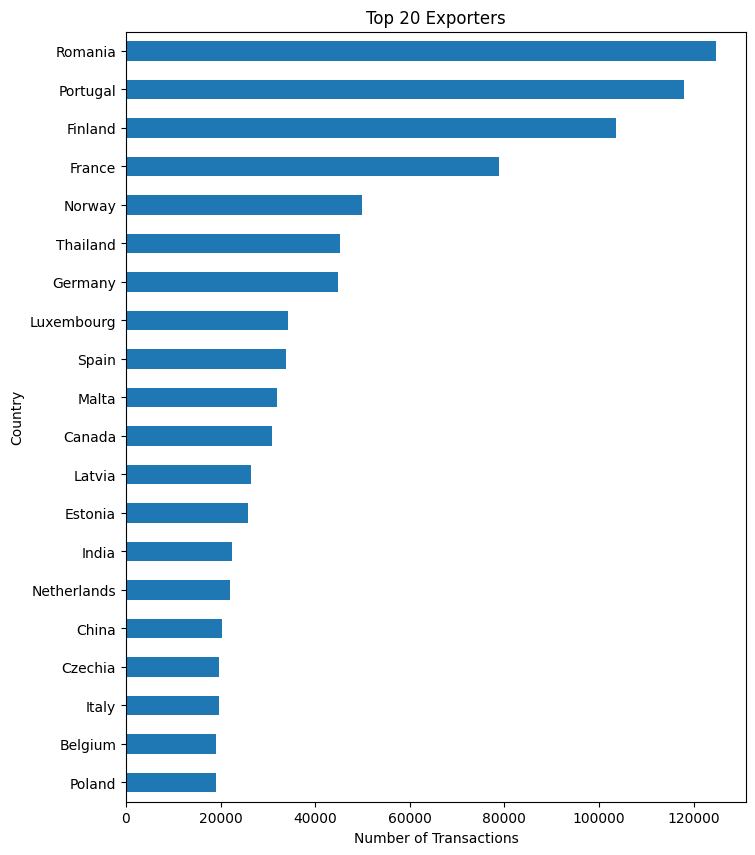

In [41]:
# From df_export
df_export['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Exporters")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

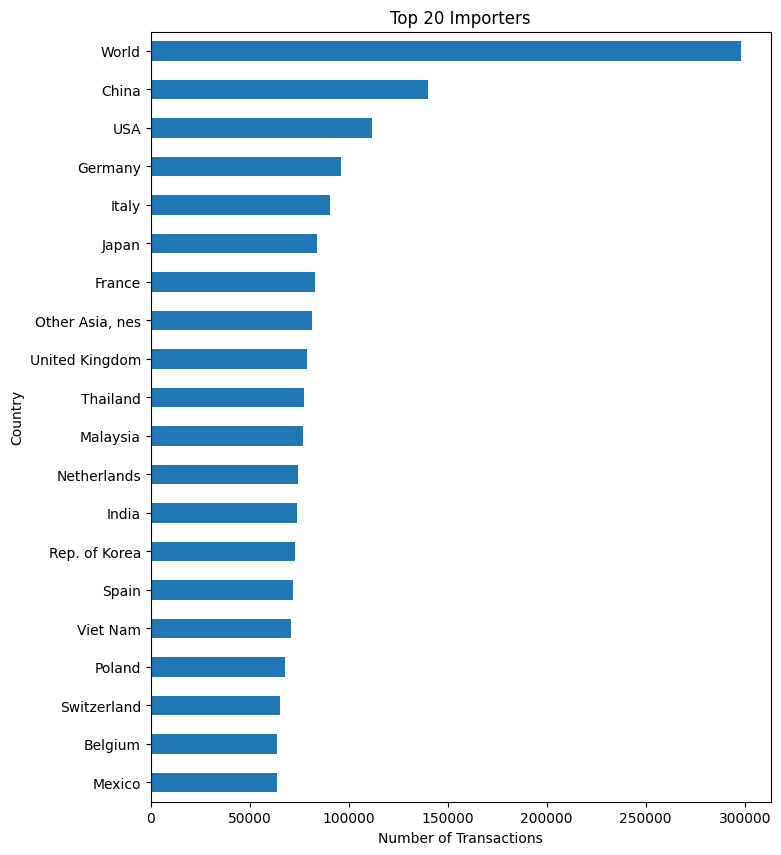

In [42]:
# From df_import
df_import['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Importers

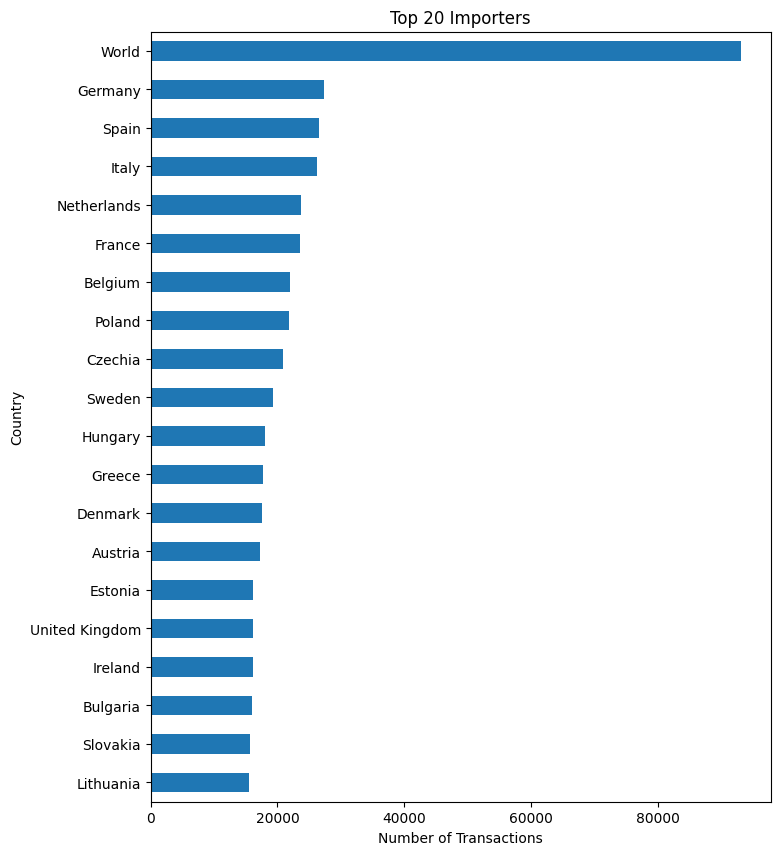

In [43]:
# From df_export
df_export['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

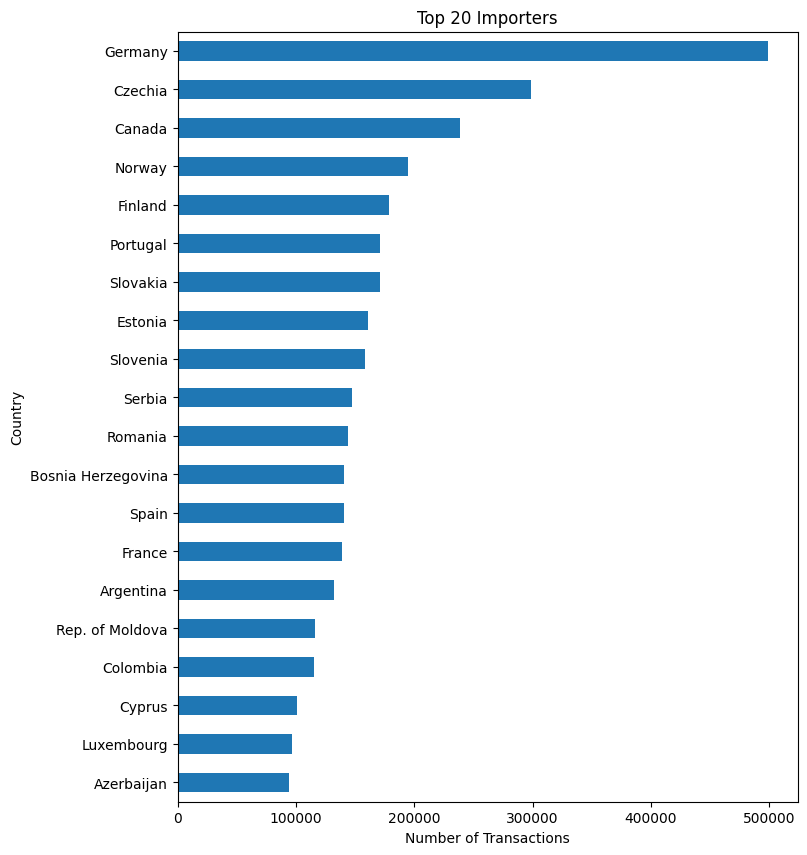

In [44]:
# From df_import
df_import['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Insight:
We can take a data either import or export from both export report or import report. However, we will have some aggregation data from the opposite report such as taking an export data from import report which exporter will be as 'partner' and the 'reporter' will be the import country. The reporter somehow create a aggregation data such as 'World' as their 'partner'. So we have to focus on the 'reporter' only to avoid aggregation data.

# Outlier Check

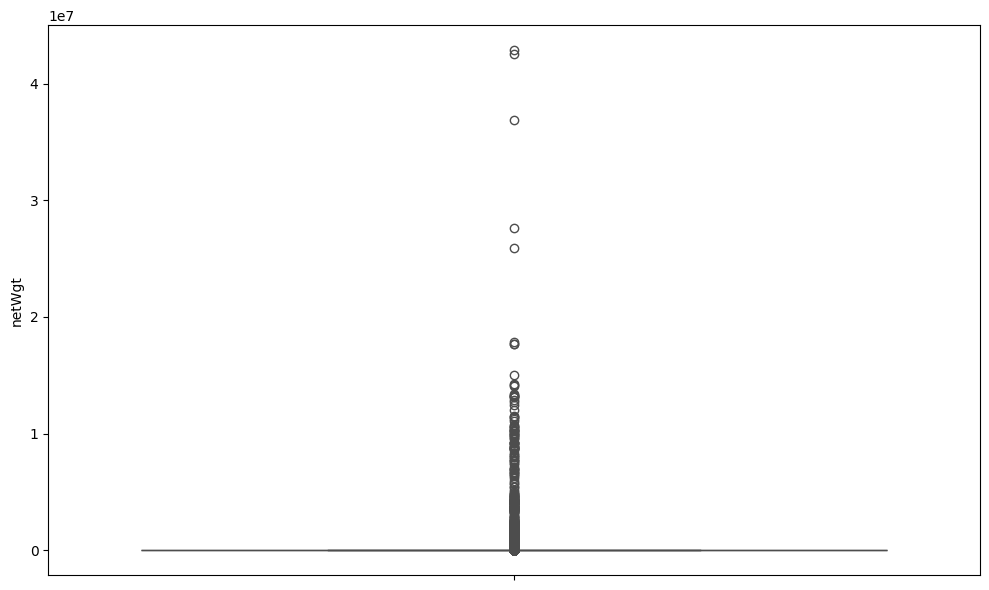

In [45]:
# Check outliers
numerical_columns = df_export.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=df_export[numerical_columns[i]], color='blue')
    plt.tight_layout()

Since the operations value is the part that has outliers, we will keep the outliers, to keep the original information.

# Export Data for PBI uses

In [46]:
#df_export.to_excel('df_export.xlsx', index=False)

In [47]:
#df_import.to_excel('df_import.xlsx', index=False)

## Data of the quantity

In [48]:
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [49]:
# Drop rows where 'qty' is zero in df_export
df_export_qty = df_export[df_export['qty'] != 0].reset_index(drop=True)
df_export_qty.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,2233.801633
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,2233.801633
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,2233.801633
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,2233.801633
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,2233.801633


In [50]:
zero_counts = df_export_qty.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [51]:
df_export_qty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1584791 entries, 0 to 1584790
Data columns (total 12 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   reporterCode  1584791 non-null  object 
 1   reporterDesc  1584791 non-null  object 
 2   partnerCode   1584791 non-null  object 
 3   partnerDesc   1584791 non-null  object 
 4   period        1584791 non-null  object 
 5   flowCode      1584791 non-null  object 
 6   flowDesc      1584791 non-null  object 
 7   cmdCode       1584791 non-null  object 
 8   cmdDesc       1584791 non-null  object 
 9   qty           1584791 non-null  object 
 10  fobvalue      1584791 non-null  object 
 11  netWgt        1584791 non-null  float64
dtypes: float64(1), object(11)
memory usage: 145.1+ MB


In [52]:
#df_export_qty.to_excel('df_export_qty.xlsx', index=False)

# Data Manipulation

In [53]:
# Select only columns with float or int data types from df_copy_clean
numeric_df = df_export.select_dtypes(include=['float64', 'int64'])
numeric_df.head()

,netWgt
0,2233.801633
1,2233.801633
2,2233.801633
3,2233.801633
4,2233.801633


In [54]:
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

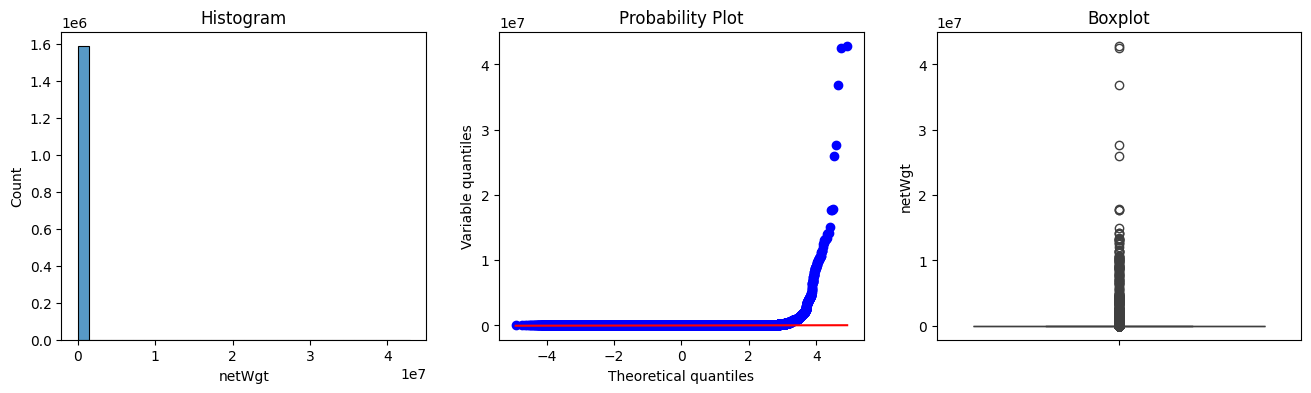

In [55]:
for col in numeric_df:
    check_plot(numeric_df, col)

There is nothing to conclude yet here.

In [56]:
# Convert fobvalue to numeric before aggregation
df_export['fobvalue'] = pd.to_numeric(df_export['fobvalue'], errors='coerce')
top_countries = df_export.groupby('reporterDesc')['fobvalue'].mean().sort_values(ascending=False).reset_index()
top_countries.head(10)

,reporterDesc,fobvalue
0,China,1.680538e+09
1,USA,1.154988e+09
2,Germany,7.948582e+08
3,Mexico,6.703559e+08
4,Japan,4.728557e+08
5,"China, Hong Kong SAR",4.695595e+08
6,Rep. of Korea,4.507224e+08
7,Viet Nam,4.083031e+08
8,Italy,3.493059e+08
9,Netherlands,3.475620e+08


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\1022818561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')


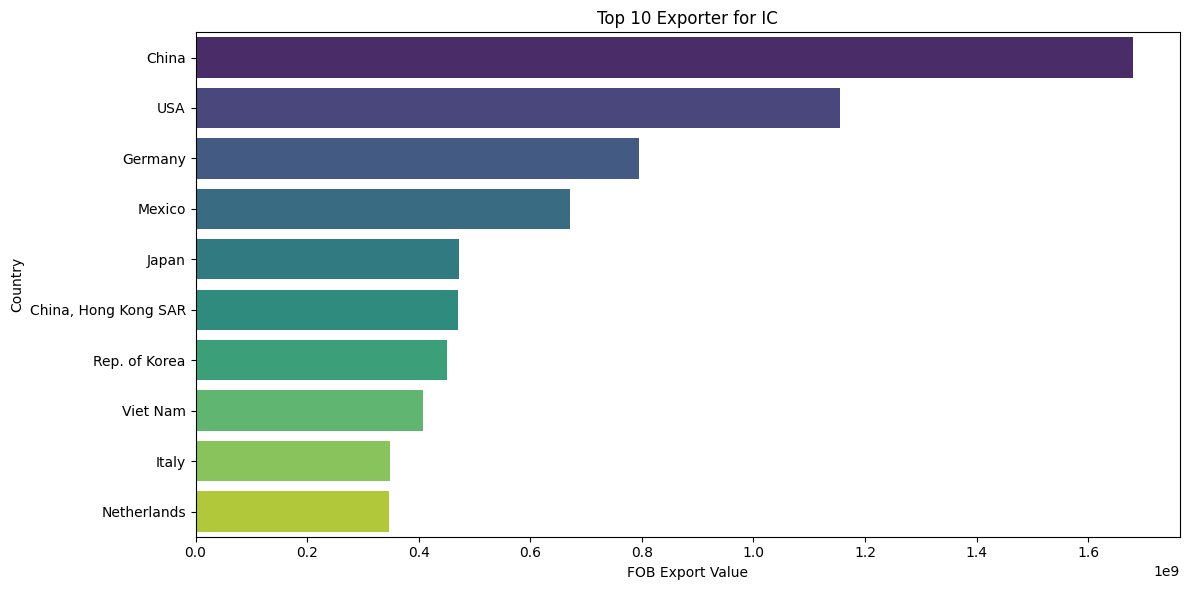

In [57]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')
plt.title('Top 10 Exporter for IC')
plt.xlabel('FOB Export Value')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

<Axes: xlabel='period'>

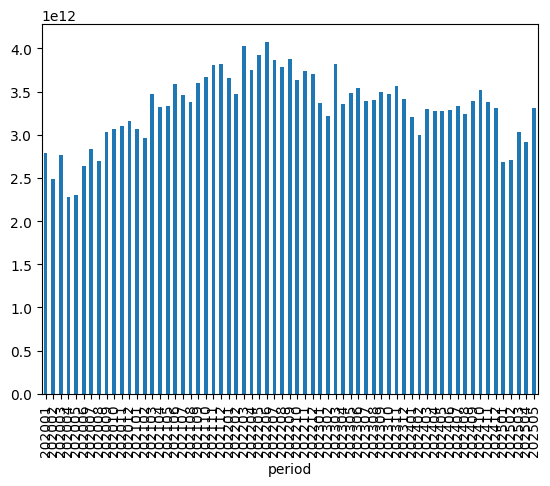

In [58]:
df_export.groupby(['period'])['fobvalue'].sum().plot(kind='bar')

In [59]:
# a. Trend analysis over time
trend_df = df_export.groupby("period")["fobvalue"].sum().reset_index()
trend_df

,period,fobvalue
0,202001,2.794026e+12
1,202002,2.490044e+12
2,202003,2.761284e+12
3,202004,2.277925e+12
4,202005,2.302294e+12
...,...,...
60,202501,2.680988e+12
61,202502,2.708961e+12
62,202503,3.031402e+12
63,202504,2.914110e+12


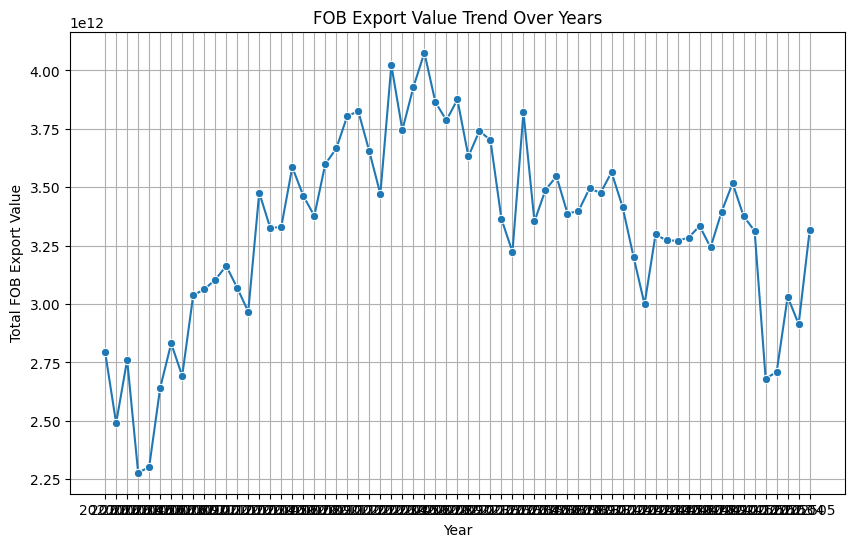

In [60]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_df, x='period', y='fobvalue', marker='o')
plt.title('FOB Export Value Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total FOB Export Value')
plt.grid(True)
plt.show()

In [61]:
# Calculate export value per kg
df_export["value_per_kg"] = df_export["fobvalue"] / df_export["netWgt"]

In [62]:
# b. Avg export value/kg by country
value_per_kg_df = df_export.groupby("reporterDesc")["value_per_kg"].mean().reset_index()
value_per_kg_df = value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)
value_per_kg_df

,reporterDesc,value_per_kg
27,China,722033.501938
123,USA,517050.280518
48,Germany,352777.540390
79,Mexico,300049.843829
61,Japan,207347.508783
28,"China, Hong Kong SAR",184630.067966
126,Viet Nam,181695.410027
101,Rep. of Korea,174614.655395
60,Italy,156738.462000
25,Canada,154948.074599


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\769833094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


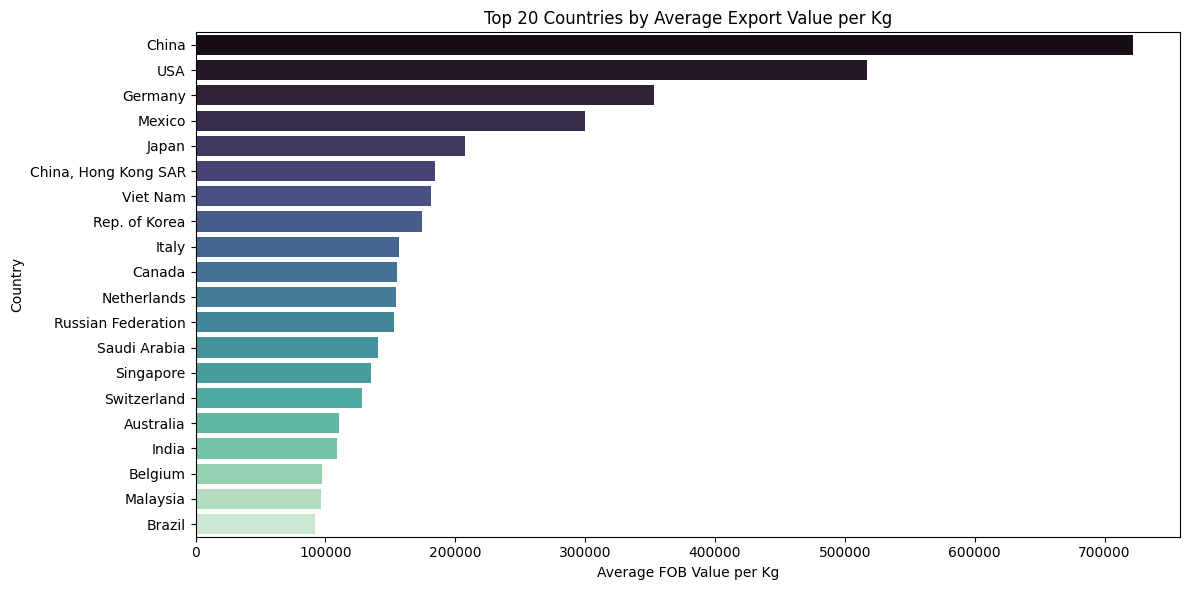

In [63]:
plt.figure(figsize=(12, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [64]:
importer_value_per_kg_df = df_export.groupby("partnerDesc").agg(
    total_fobvalue=("fobvalue", "sum"),
    total_netwgt=("netWgt", "sum")
).reset_index()

In [65]:
# Calculate value per kg
importer_value_per_kg_df["value_per_kg"] = (
    importer_value_per_kg_df["total_fobvalue"] / importer_value_per_kg_df["total_netwgt"]
)
importer_value_per_kg_df = importer_value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\491785898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\491785898.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


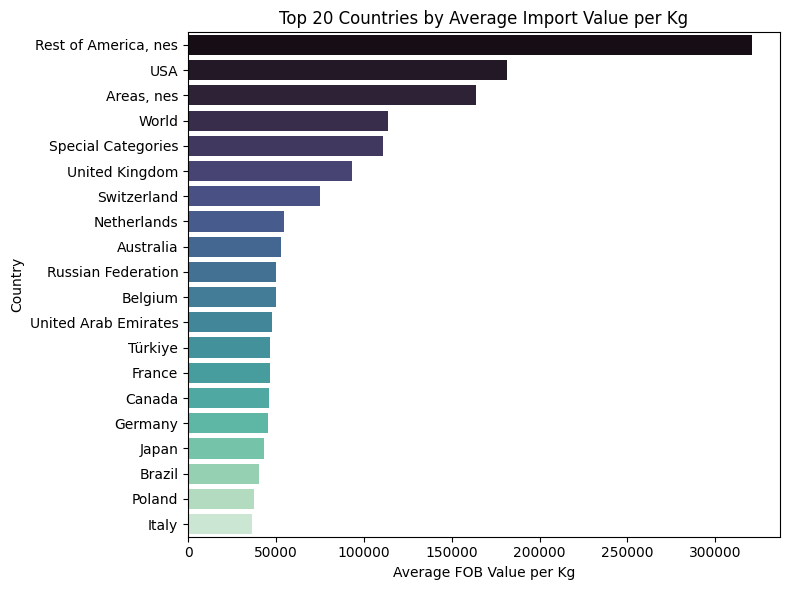

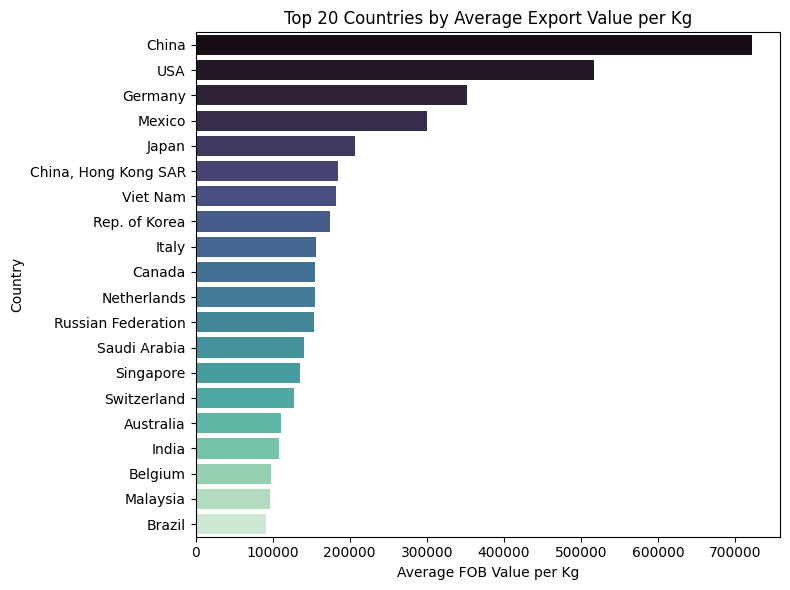

In [66]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
plt.title('Top 20 Countries by Average Import Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.figure(figsize=(8, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.show()

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\101735088.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")


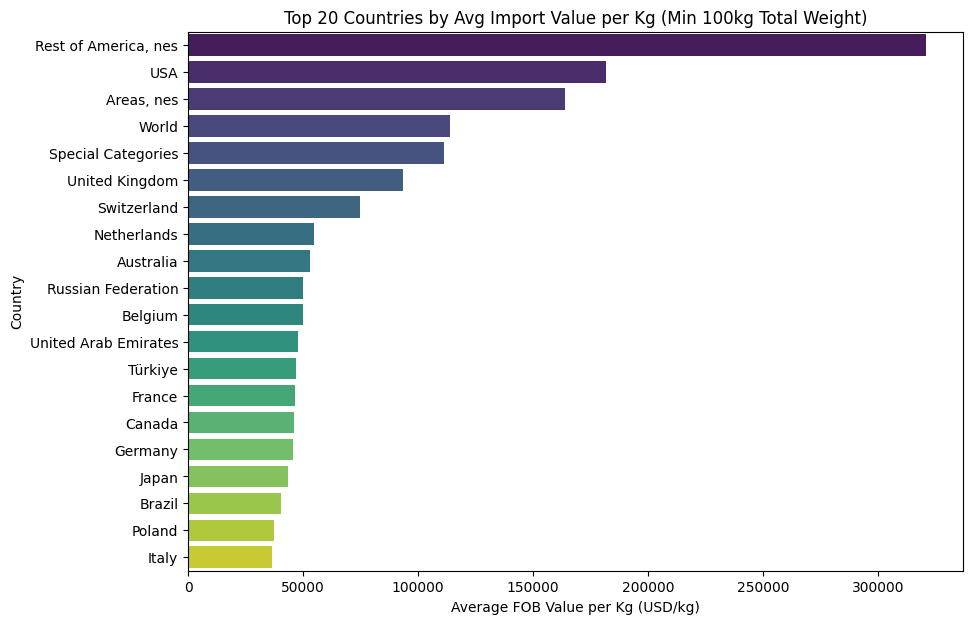

In [67]:
# Apply threshold: remove countries with too small total weight (e.g., <100kg)
filtered_df = importer_value_per_kg_df[importer_value_per_kg_df["total_netwgt"] > 100]

# Get top 20 by FOB value
top_importers_filtered = filtered_df.sort_values(by="value_per_kg", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")
plt.title("Top 20 Countries by Avg Import Value per Kg (Min 100kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.show()


Move to PBI to make a complete visualization, and conclusion. Business recommendation is in Powerpoint.

In [68]:
# Top exporters by FOB
top_exp = (df_copy_export.groupby('reporterDesc')['fobvalue']
                 .sum().sort_values(ascending=False).head(10))

# Convert netWgt and fobvalue to numeric
df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
df_copy_export['fobvalue'] = pd.to_numeric(df_copy_export['fobvalue'], errors='coerce')

# Weighted $/kg with a weight floor (e.g., 1,000 kg)
g = df_copy_export[(df_copy_export['netWgt'] > 0) & (df_copy_export['fobvalue'] > 0)] \
        .groupby('reporterDesc').agg(val=('fobvalue','sum'),
                                     wgt=('netWgt','sum'))
g['usd_per_kg'] = g['val'] / g['wgt']
price_rank = g[g['wgt'] >= 1000].sort_values('usd_per_kg', ascending=False).head(10)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\535947027.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\535947027.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['fobvalue'] = pd.to_numeric(df_copy_export['fobvalue'], errors='coerce')


x value (usd_per_kg):
reporterDesc
USA                   517050.280518
Mexico                291342.138746
Russian Federation    173029.087085
Switzerland           159863.384230
Canada                156724.071300
Saudi Arabia          128902.558307
Germany               114316.352558
Australia             113122.954179
India                 105221.915661
Viet Nam              100912.111599
Name: usd_per_kg, dtype: float64


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\2912927662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\2912927662.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


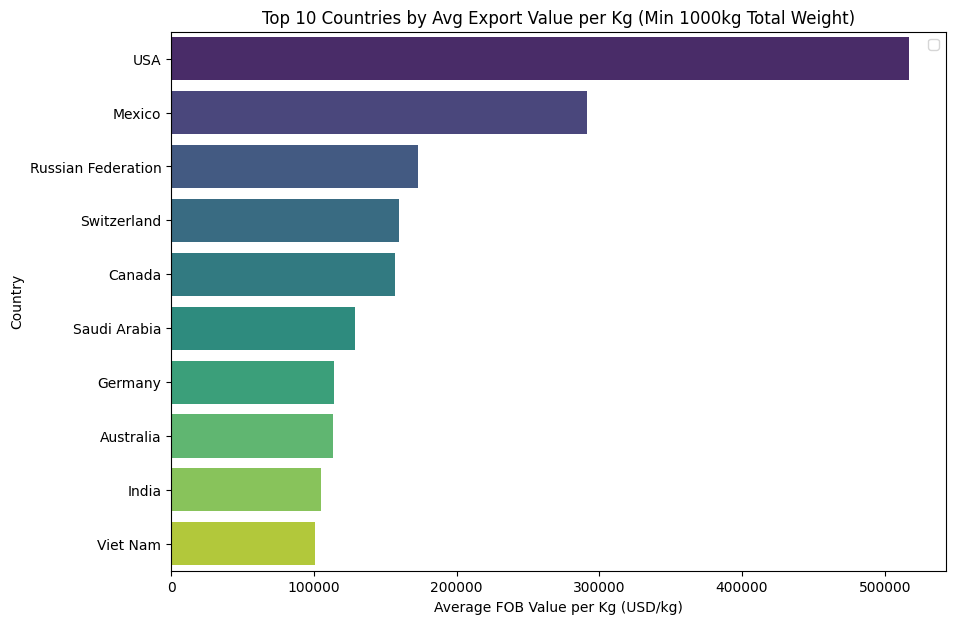

In [69]:
# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
plt.title("Top 10 Countries by Avg Export Value per Kg (Min 1000kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.legend()
print("x value (usd_per_kg):")
print(price_rank['usd_per_kg'])
plt.show()

# Machine learning

In [70]:
# ---------- 1) Parameters ---------------------------------------------------------
value_col = "total_value"   # <- set to "total_kg" if you want Net Weight instead
season    = 12
horizon   = 7               # 6 months of future forecast

In [80]:
def decomp_forecast_multiplicative_flex(
    monthly_df, value_col="total_value", 
    ma_window=12,          # <-- change to 6 for MA6
    season=12,             # <-- keep 12 unless you truly have 6-month seasonality
    horizon=7
):
    """
    Multiplicative decomposition with a flexible MA window for trend (CMA)
    and a possibly different seasonal period for seasonal indices.
    """
    df = monthly_df[["ref_date", value_col]].dropna().copy()
    df = df.sort_values("ref_date").reset_index(drop=True)
    s = df.set_index("ref_date")[value_col].astype(float)

    # Ensure continuous monthly index
    idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(idx)

    if len(s) < ma_window + 1:
        raise ValueError(f"Need at least {ma_window+1} months; have {len(s)}.")

    # ---- CMA (centered moving average) using ma_window ----
    if ma_window % 2 == 1:
        # odd window: true centered rolling mean
        cma = s.rolling(ma_window, center=True).mean()
    else:
        # even window: average adjacent MA to center between months
        ma = s.rolling(ma_window, center=False).mean()
        cma = (ma + ma.shift(-1)) / 2.0

    # ---- Seasonal ratios: Actual / CMA (only where CMA exists) ----
    ratios = (s / cma).dropna()

    # ---- Seasonal indices (SI) ----
    # Option A (default): calendar seasonality (12 months by month-of-year)
    # If `season == 12`, use calendar months. Otherwise, use a generic cycle index 1..season.
    if season == 12:
        # average ratios by calendar month number
        si_by = ratios.groupby(ratios.index.month).mean()
        index_labels = pd.Index(range(1, 13), name="month")
    else:
        # generic cycle index repeating 1..season
        cyc_idx = pd.Series(np.arange(len(s)), index=s.index) % season + 1
        # align to ratios index
        cyc_idx = cyc_idx.reindex(ratios.index)
        si_by = ratios.groupby(cyc_idx).mean()
        index_labels = pd.Index(range(1, season + 1), name="cycle")

    # Fill missing buckets then normalize to mean = 1
    si_by = si_by.reindex(index_labels)
    if si_by.isna().any():
        si_by = si_by.fillna(si_by.dropna().mean())
    si_norm = si_by / si_by.mean()

    # ---- Expand SI to the full timeline ----
    si_series = pd.Series(index=s.index, dtype=float)
    if season == 12:
        for m in range(1, 13):
            si_series[s.index.month == m] = float(si_norm.loc[m])
    else:
        cyc_full = (np.arange(len(s)) % season) + 1
        for k in range(1, season + 1):
            si_series.iloc[cyc_full == k] = float(si_norm.loc[k])

    # ---- Deseasonalize and fit linear trend y ≈ a + b t ----
    deseason = s / si_series
    mask = deseason.notna().values
    t = np.arange(len(deseason))[mask]
    y = deseason[mask].values
    if len(t) < 2:
        raise ValueError("Not enough points to fit a trend.")
    b, a = np.polyfit(t, y, deg=1)  # slope b, intercept a

    trend_hat = pd.Series(np.nan, index=deseason.index)
    trend_hat.iloc[mask] = a + b * t

    # Fitted, re-seasonalized (in-sample)
    ltwS_fitted = trend_hat * si_series

    # ---- Forecast next horizon months ----
    last_date = s.index.max()
    future_idx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    t_future   = np.arange(len(deseason), len(deseason) + horizon)
    trend_future = a + b * t_future

    # Seasonal indices for future months
    if season == 12:
        si_future = pd.Series([float(si_norm.loc[m]) for m in future_idx.month], index=future_idx)
    else:
        cyc_future = (np.arange(len(s), len(s) + horizon) % season) + 1
        si_future = pd.Series([float(si_norm.loc[k]) for k in cyc_future], index=future_idx)

    yhat_future = trend_future * si_future.values

    # ---- Outputs ----
    components = pd.DataFrame({
        "ref_date": s.index,
        "Actual": s.values,
        "CMA": cma.values,
        "SI": si_series.values,
        "Deseasonalized": deseason.values,
        "Trend(a+bt)": trend_hat.values,
        "LTwS_fitted": ltwS_fitted.values
    }).set_index("ref_date")

    forecast = pd.DataFrame({
        "ref_date": future_idx,
        "Trend(a+bt)_future": trend_future,
        "SI_future": si_future.values,
        "Forecast_LTwS": yhat_future
    })

    # In-sample accuracy
    common = components.dropna(subset=["Actual","Trend(a+bt)","LTwS_fitted"])
    MAD_LT   = float(np.mean(np.abs(common["Actual"] - common["Trend(a+bt)"]))) if not common.empty else np.nan
    MAD_LTwS = float(np.mean(np.abs(common["Actual"] - common["LTwS_fitted"]))) if not common.empty else np.nan

    meta = {"intercept_a": a, "slope_b": b, "MAD_LT": MAD_LT, "MAD_LTwS": MAD_LTwS,
            "ma_window": ma_window, "season": season}
    return components, forecast, si_norm, meta

In [81]:
# ---------- 3) Prepare monthly data and run decomposition -------------------------
# Aggregate export value by month
monthly = (
    df_export.groupby('period')['fobvalue']
    .sum()
    .reset_index()
    .rename(columns={'period': 'ref_date', 'fobvalue': 'total_value'})
)
# Convert ref_date to datetime for decomposition
monthly['ref_date'] = pd.to_datetime(monthly['ref_date'], format='%Y%m')

components, forecast_6, seasonal_indices, meta = decomp_forecast_multiplicative_flex(
    monthly, value_col="total_value", ma_window=6, season=6, horizon=6
)


In [82]:
# ---------- 4) Excel-like table (history + future) -------------------------------
hist_tbl = components.reset_index().copy()
hist_tbl["month_label"] = hist_tbl["ref_date"].dt.strftime("%Y-%m")
# Merge future rows (with NaNs for in-sample-only columns)
future_tbl = forecast_6.copy()
future_tbl["month_label"] = future_tbl["ref_date"].dt.strftime("%Y-%m")
table_full = pd.concat([
    hist_tbl[["ref_date","month_label","Actual","CMA","SI","Deseasonalized","Trend(a+bt)","LTwS_fitted"]],
    future_tbl[["ref_date","month_label","Trend(a+bt)_future","SI_future","Forecast_LTwS"]]
], ignore_index=True).sort_values("ref_date").reset_index(drop=True)

print(f"Using metric: {value_col}  (set value_col='total_kg' for Net Weight)")
print(f"Linear trend: y = a + b*t,  a={meta['intercept_a']:.3g},  b={meta['slope_b']:.3g}")
print(f"MAD LT (Actual vs Trend):       {meta['MAD_LT']:.3g}")
print(f"MAD LTwS (Actual vs Trend*SI):  {meta['MAD_LTwS']:.3g}")

display(table_full.tail(20))  # show the last rows including the future 6 months


Using metric: total_value  (set value_col='total_kg' for Net Weight)
Linear trend: y = a + b*t,  a=3.17e+12,  b=4.72e+09
MAD LT (Actual vs Trend):       3.09e+11
MAD LTwS (Actual vs Trend*SI):  2.98e+11


,ref_date,month_label,Actual,CMA,SI,Deseasonalized,Trend(a+bt),LTwS_fitted,Trend(a+bt)_future,SI_future,Forecast_LTwS
51,2024-04-01,2024-04,3.272380e+12,3.267779e+12,1.001218,3.268400e+12,3.411244e+12,3.415398e+12,NaN,NaN,NaN
52,2024-05-01,2024-05,3.271208e+12,3.232327e+12,1.016170,3.219155e+12,3.415962e+12,3.471198e+12,NaN,NaN,NaN
53,2024-06-01,2024-06,3.284416e+12,3.232291e+12,1.024637,3.205442e+12,3.420681e+12,3.504957e+12,NaN,NaN,NaN
54,2024-07-01,2024-07,3.334472e+12,3.263574e+12,0.976378,3.415143e+12,3.425399e+12,3.344486e+12,NaN,NaN,NaN
55,2024-08-01,2024-08,3.242478e+12,3.291937e+12,0.944651,3.432461e+12,3.430118e+12,3.240265e+12,NaN,NaN,NaN
56,2024-09-01,2024-09,3.395185e+12,3.320454e+12,1.036945,3.274218e+12,3.434836e+12,3.561737e+12,NaN,NaN,NaN
57,2024-10-01,2024-10,3.517545e+12,3.349622e+12,1.001218,3.513266e+12,3.439555e+12,3.443743e+12,NaN,NaN,NaN
58,2024-11-01,2024-11,3.376069e+12,3.360744e+12,1.016170,3.322348e+12,3.444273e+12,3.499966e+12,NaN,NaN,NaN
59,2024-12-01,2024-12,3.313017e+12,3.308671e+12,1.024637,3.233356e+12,3.448991e+12,3.533965e+12,NaN,NaN,NaN
60,2025-01-01,2025-01,2.680988e+12,3.209754e+12,0.976378,2.745849e+12,3.453710e+12,3.372128e+12,NaN,NaN,NaN


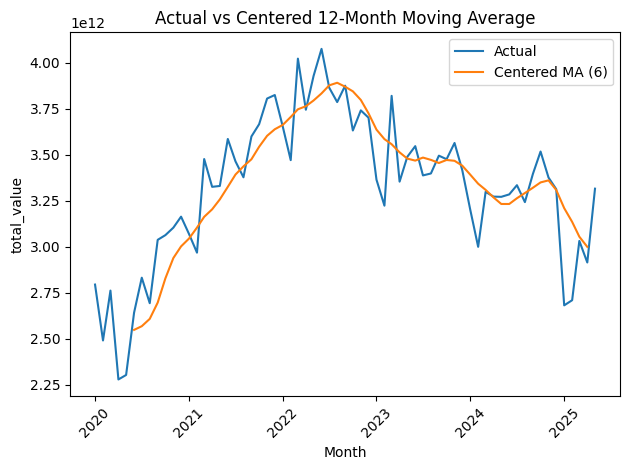

In [83]:
# ---------- 5) Plots like your Excel --------------------------------------------
# A) CMA vs Actual (smoothed level)
plt.figure()
plt.plot(components.index, components["Actual"], label="Actual")
plt.plot(components.index, components["CMA"], label="Centered MA (6)")
plt.title("Actual vs Centered 12-Month Moving Average")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

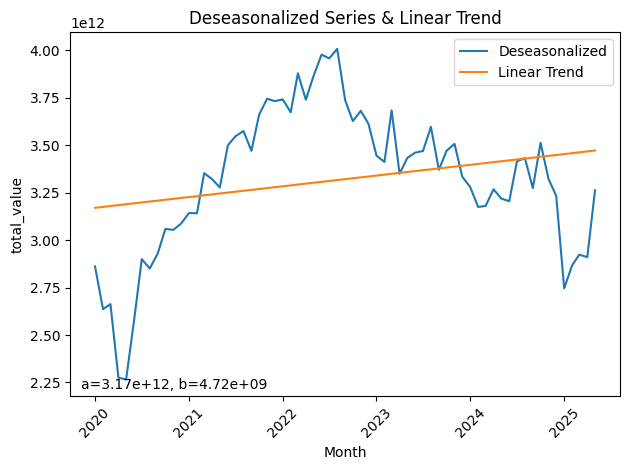

In [84]:
# B) Linear Trend on deseasonalized, with intercept/slope annotated
plt.figure()
plt.plot(components.index, components["Deseasonalized"], label="Deseasonalized")
plt.plot(components.index, components["Trend(a+bt)"], label="Linear Trend")
plt.title("Deseasonalized Series & Linear Trend")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend()
# annotate a and b
x0, x1 = 0, len(components.dropna(subset=["Trend(a+bt)"])) - 1
plt.text(0.02, 0.02, f"a={meta['intercept_a']:.3g}, b={meta['slope_b']:.3g}",
         transform=plt.gca().transAxes)
plt.tight_layout(); plt.show()

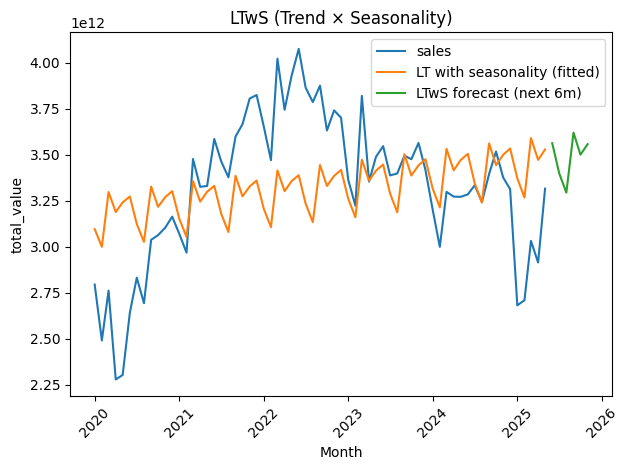

In [85]:
# C) Linear Trend WITH Seasonality (LTwS): show history (fitted) + future 6m
plt.figure()
# Use fitted LTwS where available
plt.plot(components.index, components["Actual"], label="sales")
plt.plot(components.index, components["LTwS_fitted"], label="LT with seasonality (fitted)")
# Append future forecast
plt.plot(forecast_6["ref_date"], forecast_6["Forecast_LTwS"], label="LTwS forecast (next 6m)")
plt.title("LTwS (Trend × Seasonality)")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

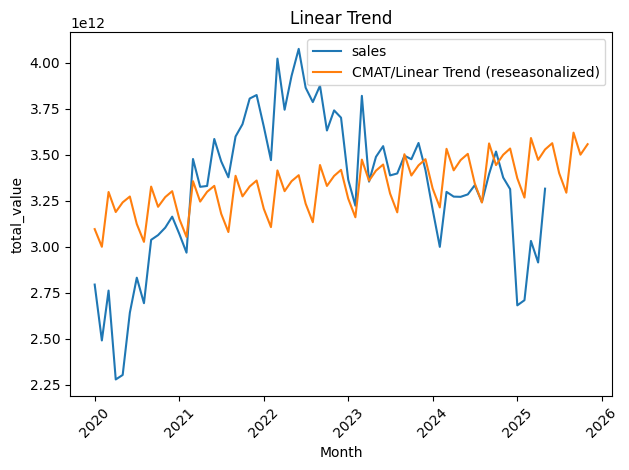

In [86]:
# D) (Optional) “Linear Trend” view like your top chart:
#    plot original (Actual) against reseasonalized trend (fitted + future)
plt.figure()
plt.plot(components.index, components["Actual"], label="sales")
# build a single series that stitches fitted LTwS + future LTwS
stitched = pd.concat([
    components["LTwS_fitted"].dropna().rename("LT reseasonalized (in-sample)"),
    forecast_6.set_index("ref_date")["Forecast_LTwS"].rename("LT reseasonalized (future)")
]).sort_index()
plt.plot(stitched.index, stitched.values, label="CMAT/Linear Trend (reseasonalized)")
plt.title("Linear Trend")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

Seasonality window: last 3y starting 2022-05-01
Trend fit from: 2022-01-01  |  MA window: 12
Chosen shrink λ = 0.0  (lower MAE on last-12)


,Month,SI_recent,SI_shrunk(λ=0.0)
0,Jan,0.909301,0.909301
1,Feb,0.885402,0.885402
2,Mar,1.011978,1.011978
3,Apr,0.959152,0.959152
4,May,1.026507,1.026507
5,Jun,1.048443,1.048443
6,Jul,1.020038,1.020038
7,Aug,1.005951,1.005951
8,Sep,1.040649,1.040649
9,Oct,1.031858,1.031858


,ref_date,Trend_only,SI_used,Forecast_LTwS
0,2025-06-01,3.002889e+12,1.048443,3.148359e+12
1,2025-07-01,2.980988e+12,1.020038,3.040722e+12
2,2025-08-01,2.959087e+12,1.005951,2.976695e+12
3,2025-09-01,2.937185e+12,1.040649,3.056580e+12
4,2025-10-01,2.915284e+12,1.031858,3.008160e+12
5,2025-11-01,2.893383e+12,1.039645,3.008091e+12
6,2025-12-01,2.871481e+12,1.021075,2.931997e+12


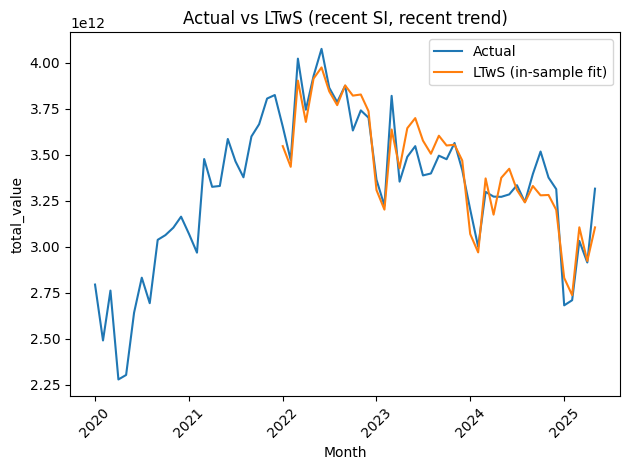

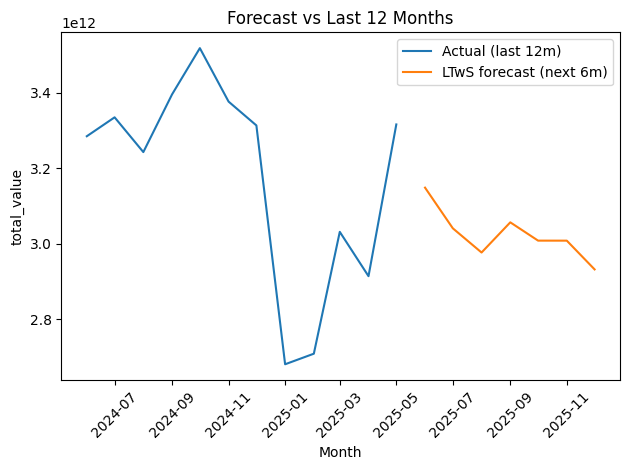

In [91]:


# -- 0) Build/refresh monthly if not present (FOB target; switch to total_kg if you prefer) --
if "monthly" not in globals():
    dfe = df_copy_export.copy()
    for c in ["primaryValue","fobvalue","netWgt"]:
        if c in dfe.columns: dfe[c] = pd.to_numeric(dfe[c], errors="coerce")
    dfe["value"] = dfe["primaryValue"]; dfe.loc[dfe["value"].isna(), "value"] = dfe["fobvalue"]
    dfe = dfe[(dfe["value"] > 0) & (dfe["netWgt"] > 0)]
    dfe["period"] = pd.to_numeric(dfe["period"].astype(str).str.extract(r"(\d{6})")[0], errors="coerce").astype("Int64")
    dfe = dfe[dfe["period"].notna()]
    yy = (dfe["period"] // 100).astype(int); mm = (dfe["period"] % 100).astype(int)
    dfe["ref_date"] = pd.to_datetime(dict(year=yy, month=mm, day=1))
    monthly = (dfe.groupby("ref_date", as_index=False)
                 .agg(total_value=("value","sum"), total_kg=("netWgt","sum"))
               ).sort_values("ref_date").reset_index(drop=True)

# ---- PARAMETERS YOU CAN TUNE ----------------------------------------------------
value_col      = "total_value"   # change to "total_kg" to forecast weight
season         = 12              # monthly seasonality
ma_window      = 12              # 12 is classic; use 6 if you want a quicker smoother
si_years       = 3               # use last N years to compute seasonality
recent_trend_from = "2022-01-01" # fit trend from this month onward (handles structural breaks)
horizon        = 7               # months ahead

# ---- 1) Build a continuous monthly series --------------------------------------
df = monthly[["ref_date", value_col]].dropna().sort_values("ref_date").reset_index(drop=True)
s  = df.set_index("ref_date")[value_col].astype(float)
full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
s = s.reindex(full_idx)

# ---- 2) Centered moving average for trend base (MA window = ma_window) ---------
if ma_window % 2 == 1:
    cma = s.rolling(ma_window, center=True).mean()
else:
    ma  = s.rolling(ma_window, center=False).mean()
    cma = (ma + ma.shift(-1)) / 2.0

# ---- 3) Seasonal indices from RECENT years only --------------------------------
cutoff_si = (s.index.max() - pd.DateOffset(years=si_years)).replace(day=1)
si_slice  = s[s.index >= cutoff_si]
cma_slice = cma[cma.index >= cutoff_si]
ratios    = (si_slice / cma_slice).dropna()

# average ratios by calendar month, fill missing months, normalize to mean=1
si_by_m = ratios.groupby(ratios.index.month).mean()
all_m   = pd.Index(range(1, season+1), dtype=int)
si_by_m = si_by_m.reindex(all_m)
if si_by_m.isna().any():
    si_by_m = si_by_m.fillna(si_by_m.dropna().mean())
si_raw  = si_by_m / si_by_m.mean()  # normalized SI (recent only)

# ---- 4) (Auto) shrink SI toward 1.0 using a tiny CV on the last 12 months -----
def build_si_series(si_dict):
    si_ser = pd.Series(index=s.index, dtype=float)
    for m in range(1, season+1):
        si_ser[s.index.month == m] = float(si_dict.loc[m])
    return si_ser

def ltwS_forecast_from_params(si_dict, trend_start=None):
    # deseasonalize with given SI
    si_ser = build_si_series(si_dict)
    d = s / si_ser
    # trend window
    if trend_start is not None:
        mask = d.notna() & (d.index >= pd.Timestamp(trend_start))
    else:
        mask = d.notna()
    t = np.arange(len(d))[mask.values]
    y = d[mask].values
    if len(t) < 2: 
        return None, None, None, None, None
    b, a = np.polyfit(t, y, 1)
    # fitted (in-sample) reseasonalized
    trend_hat = pd.Series(np.nan, index=d.index)
    trend_hat.iloc[mask] = a + b * t
    fit = trend_hat * si_ser
    return a, b, si_ser, d, fit

# pick lambda in {0.0, 0.2, 0.3, 0.4, 0.5}
candidates = [0.0, 0.2, 0.3, 0.4, 0.5]
scores = []
last12 = s.dropna().tail(12)
for lam in candidates:
    si_shrunk = (1-lam)*si_raw + lam*1.0
    a,b,si_ser,d,fit = ltwS_forecast_from_params(si_shrunk, trend_start=recent_trend_from)
    if fit is None:
        scores.append((lam, np.inf))
        continue
    # score on last 12 months where both actual & fit exist
    common = pd.concat([last12.rename("y"), fit.rename("fit")], axis=1).dropna()
    mae = mean_absolute_error(common["y"], common["fit"]) if not common.empty else np.inf
    scores.append((lam, mae))

best_lambda, best_mae = sorted(scores, key=lambda x: x[1])[0]
si_best = (1-best_lambda)*si_raw + best_lambda*1.0

# ---- 5) Final fit with best SI and recent trend window -------------------------
a,b,si_series,deseason,fit_insample = ltwS_forecast_from_params(si_best, trend_start=recent_trend_from)

# ---- 6) Forecast next 6 months -------------------------------------------------
last_date = s.index.max()
fidx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
t_future = np.arange(len(deseason), len(deseason) + horizon)
trend_future = a + b * t_future
si_future = pd.Series([float(si_best.loc[m]) for m in fidx.month], index=fidx)
yhat_future = trend_future * si_future.values

forecast = pd.DataFrame({
    "ref_date": fidx,
    "Trend_only": trend_future,
    "SI_used": si_future.values,
    "Forecast_LTwS": yhat_future
})

# ---- 7) Diagnostics: show SI table and what changed ---------------------------
si_table = pd.DataFrame({
    "Month": [pd.Timestamp(2000, m, 1).strftime("%b") for m in range(1,13)],
    "SI_recent": si_raw.values,
    f"SI_shrunk(λ={best_lambda})": si_best.values
})

print(f"Seasonality window: last {si_years}y starting {cutoff_si.date()}")
print(f"Trend fit from: {recent_trend_from}  |  MA window: {ma_window}")
print(f"Chosen shrink λ = {best_lambda}  (lower MAE on last-12)")
display(si_table)
display(forecast)

# ---- 8) Plots: fit vs actual; forecast vs last 12m ----------------------------
plt.figure()
plt.plot(s.index, s.values, label="Actual")
plt.plot(fit_insample.index, fit_insample.values, label="LTwS (in-sample fit)")
plt.title("Actual vs LTwS (recent SI, recent trend)")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
hist = s.tail(12)
plt.plot(hist.index, hist.values, label="Actual (last 12m)")
plt.plot(forecast["ref_date"], forecast["Forecast_LTwS"], label="LTwS forecast (next 6m)")
plt.title("Forecast vs Last 12 Months")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
# =================================================================================


Trend fit from: 2020-01-01 → 2025-05-01  (n months used: 65)
MA window=12, SI window=all, shrink λ=0.0


,Actual,CMA,SI_used,Deseasonalized,Trend_in_sample
ref_date,,,,,
2024-03-01,3.298153e+12,3.382195e+12,1.040578,3.169539e+12,3.410564e+12
2024-04-01,3.272380e+12,3.369738e+12,0.975746,3.353720e+12,3.415277e+12
2024-05-01,3.271208e+12,3.349734e+12,1.007842,3.245754e+12,3.419990e+12
2024-06-01,3.284416e+12,3.336580e+12,1.038164,3.163678e+12,3.424702e+12
2024-07-01,3.334472e+12,3.327872e+12,1.003465,3.322959e+12,3.429415e+12
2024-08-01,3.242478e+12,3.317218e+12,0.982516,3.300178e+12,3.434128e+12
2024-09-01,3.395185e+12,3.314796e+12,1.020404,3.327295e+12,3.438840e+12
2024-10-01,3.517545e+12,3.308701e+12,1.014623,3.466851e+12,3.443553e+12
2024-11-01,3.376069e+12,3.296535e+12,1.025861,3.290963e+12,3.448266e+12


,ref_date,LT_forecast,SI_future,LTwS_forecast
0,2025-06-01,3.481254e+12,1.038164,3.614111e+12
1,2025-07-01,3.485967e+12,1.003465,3.498044e+12
2,2025-08-01,3.490679e+12,0.982516,3.429649e+12
3,2025-09-01,3.495392e+12,1.020404,3.566713e+12
4,2025-10-01,3.500105e+12,1.014623,3.551285e+12
5,2025-11-01,3.504817e+12,1.025861,3.595454e+12


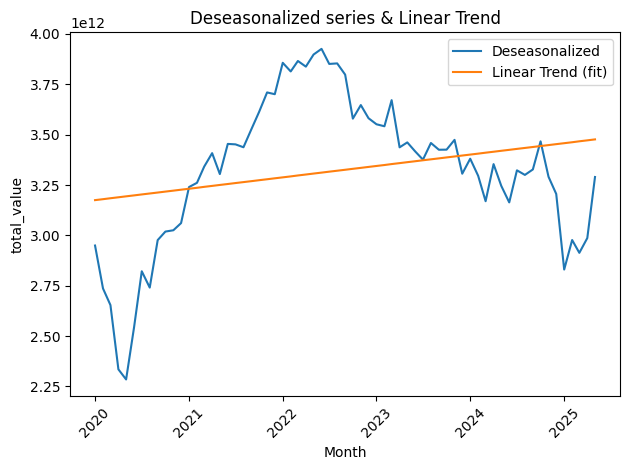

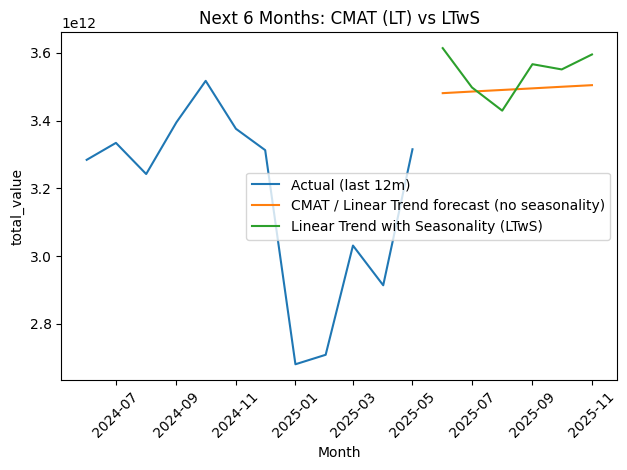

In [93]:
# --------------------- SETTINGS you can tweak ---------------------
value_col         = "total_value"   # or "total_kg"
season            = 12              # monthly seasonality
ma_window         = 12              # 12 = classic CMA; 6 = more responsive
si_years          = None            # None = use all years; or set to 3 to use last 3y for SI
recent_trend_from = None            # e.g. "2023-01-01" to fit trend on recent regime only
shrink_lambda     = 0.0             # 0.0 = raw SI; 0.3–0.5 shrinks SI toward 1.0 to stabilize
horizon           = 6               # months ahead to forecast

# --------------------- Build continuous monthly series ---------------------
df = monthly[["ref_date", value_col]].dropna().sort_values("ref_date").reset_index(drop=True)
s  = df.set_index("ref_date")[value_col].astype(float)
full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
s = s.reindex(full_idx)

# --------------------- CMA from moving average ---------------------
if ma_window % 2 == 1:
    cma = s.rolling(ma_window, center=True).mean()
else:
    ma  = s.rolling(ma_window, center=False).mean()
    cma = (ma + ma.shift(-1)) / 2.0

# --------------------- Seasonal indices (SI) ----------------------
if si_years is not None:
    cutoff_si = (s.index.max() - pd.DateOffset(years=si_years)).replace(day=1)
    s_for_si, cma_for_si = s[s.index >= cutoff_si], cma[cma.index >= cutoff_si]
else:
    s_for_si, cma_for_si = s, cma

ratios   = (s_for_si / cma_for_si).dropna()
si_by_m  = ratios.groupby(ratios.index.month).mean()  # month=1..12
all_m    = pd.Index(range(1, season+1), dtype=int)
si_by_m  = si_by_m.reindex(all_m)
if si_by_m.isna().any():
    si_by_m = si_by_m.fillna(si_by_m.dropna().mean())
si_raw   = si_by_m / si_by_m.mean()                   # normalize mean=1
si_shrunk= (1 - shrink_lambda) * si_raw + shrink_lambda * 1.0

# Expand SI to full timeline (per month-of-year)
si_series = pd.Series(index=s.index, dtype=float)
for m in range(1, season+1):
    si_series[s.index.month == m] = float(si_shrunk.loc[m])

# --------------------- Deseasonalize & fit LINEAR TREND ---------------------
deseason = s / si_series  # remove seasonality
if recent_trend_from:
    mask = deseason.notna() & (deseason.index >= pd.Timestamp(recent_trend_from))
else:
    mask = deseason.notna()

t = np.arange(len(deseason))[mask.values]
y = deseason[mask].values
if len(t) < 2:
    raise ValueError("Not enough points in the chosen window to fit a trend.")
b, a = np.polyfit(t, y, 1)                 # slope b, intercept a
trend_hat = pd.Series(np.nan, index=deseason.index)
trend_hat.iloc[mask] = a + b * t           # in-sample trend (deseasonalized scale)

# --------------------- Build forecasts (LT and LTwS) ---------------------
last_date = s.index.max()
fidx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
t_future = np.arange(len(deseason), len(deseason) + horizon)

# 1) Linear Trend forecast (== CMAT forecast): NO seasonality added back
LT_forecast = a + b * t_future             # (units are same as original, deseasonalized is unitless)

# 2) Linear Trend WITH Seasonality (LTwS)
si_future   = pd.Series([float(si_shrunk.loc[m]) for m in fidx.month], index=fidx)
LTwS_forecast = LT_forecast * si_future.values

# --------------------- Final table (history + future) ---------------------
components = pd.DataFrame({
    "ref_date": s.index,
    "Actual": s.values,
    "CMA": cma.values,
    "SI_used": si_series.values,
    "Deseasonalized": deseason.values,
    "Trend_in_sample": trend_hat.values
}).set_index("ref_date")

forecast_tbl = pd.DataFrame({
    "ref_date": fidx,
    "LT_forecast": LT_forecast,            # == your "CMAT forecast" (no seasonality)
    "SI_future": si_future.values,
    "LTwS_forecast": LTwS_forecast         # final forecast with seasonality
})

print(f"Trend fit from: {recent_trend_from or s.index.min().date()} → {s.index.max().date()}  (n months used: {int(mask.sum())})")
print(f"MA window={ma_window}, SI window={'all' if si_years is None else f'last {si_years}y'}, shrink λ={shrink_lambda}")
display(components.tail(15))   # last 15 in-sample rows
display(forecast_tbl)          # the 2 forecast lines you asked for

# --------------------- Charts ---------------------
# A) Deseasonalized + Linear Trend (to see the fitted line)
plt.figure()
plt.plot(deseason.index, deseason.values, label="Deseasonalized")
plt.plot(trend_hat.index, trend_hat.values, label="Linear Trend (fit)")
plt.title("Deseasonalized series & Linear Trend")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# B) Actual vs both future forecasts
hist = s.tail(12)
plt.figure()
plt.plot(hist.index, hist.values, label="Actual (last 12m)")
plt.plot(fidx, LT_forecast, label="CMAT / Linear Trend forecast (no seasonality)")
plt.plot(fidx, LTwS_forecast, label="Linear Trend with Seasonality (LTwS)")
plt.title("Next 6 Months: CMAT (LT) vs LTwS")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
# ================================================================================

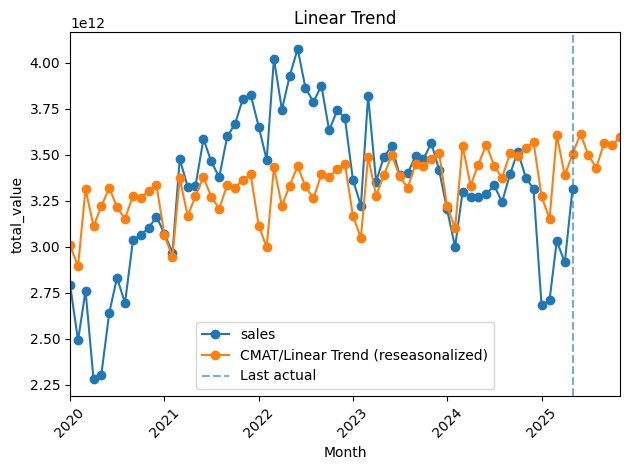

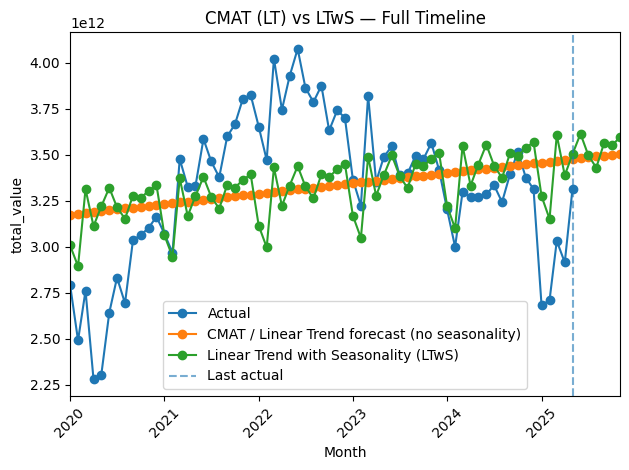

In [94]:
# 1) Gather inputs (use existing variables; else map from components/forecast_tbl)
try:
    s
except NameError:
    # Pull from the tables created in the previous block
    s = components["Actual"].dropna()                 # full actual series (index ref_date)
    trend_hat = components["Trend_in_sample"]         # linear trend (deseasonalized fit)
    si_series = components["SI_used"]                 # seasonal index per month
    fidx = pd.to_datetime(forecast_tbl["ref_date"])   # future month index
    LT_forecast = forecast_tbl["LT_forecast"].to_numpy()        # CMAT/LT forecast (no seasonality)
    LTwS_forecast = forecast_tbl["LTwS_forecast"].to_numpy()    # Trend × seasonality

# 2) Build stitched lines (history + future)
ltws_fit = (trend_hat * si_series).dropna()                       # in-sample LTwS fit
ltws_future = pd.Series(LTwS_forecast, index=fidx, name="LTwS_future")
ltws_stitched = pd.concat([ltws_fit.rename("LTwS_fit"), ltws_future]).sort_index()

lt_fit = trend_hat.dropna().rename("LT_fit")                      # in-sample trend-only
lt_future = pd.Series(LT_forecast, index=fidx, name="LT_future")
lt_stitched = pd.concat([lt_fit, lt_future]).sort_index()

last_actual = s.index.max()
xmin, xmax = s.index.min(), fidx.max()

# 3) Chart A — “Linear Trend” like your Excel (Actual vs LTwS stitched)
plt.figure()
plt.plot(s.index, s.values, marker='o', linewidth=1.5, label="sales")
plt.plot(ltws_stitched.index, ltws_stitched.values, marker='o', linewidth=1.5,
         label="CMAT/Linear Trend (reseasonalized)")
plt.axvline(last_actual, linestyle='--', alpha=0.6, label="Last actual")
plt.title("Linear Trend")
plt.xlabel("Month"); plt.ylabel(s.name or "total_value")
plt.xlim(xmin, xmax); plt.margins(x=0.01); plt.xticks(rotation=45)
plt.legend(); plt.tight_layout(); plt.show()

# 4) Chart B — Actual vs BOTH future lines (LT and LTwS), full timeline
plt.figure()
plt.plot(s.index, s.values, marker='o', linewidth=1.5, label="Actual")
plt.plot(lt_stitched.index, lt_stitched.values, marker='o', linewidth=1.5,
         label="CMAT / Linear Trend forecast (no seasonality)")
plt.plot(ltws_stitched.index, ltws_stitched.values, marker='o', linewidth=1.5,
         label="Linear Trend with Seasonality (LTwS)")
plt.axvline(last_actual, linestyle='--', alpha=0.6, label="Last actual")
plt.title("CMAT (LT) vs LTwS — Full Timeline")
plt.xlabel("Month"); plt.ylabel(s.name or "total_value")
plt.xlim(xmin, xmax); plt.margins(x=0.01); plt.xticks(rotation=45)
plt.legend(); plt.tight_layout(); plt.show()
# ============================================================================

,Actual,CMA,Trend_on_CMA,Cycle,SI,Y_with_seasonality_in
2024-03-01,3.298153e+12,3.382195e+12,3.453136e+12,0.979456,1.040578,3.519439e+12
2024-04-01,3.272380e+12,3.369738e+12,3.455534e+12,0.975171,0.975746,3.288009e+12
2024-05-01,3.271208e+12,3.349734e+12,3.457932e+12,0.968710,1.007842,3.376003e+12
2024-06-01,3.284416e+12,3.336580e+12,3.460330e+12,0.964238,1.038164,3.463916e+12
2024-07-01,3.334472e+12,3.327872e+12,3.462728e+12,0.961055,1.003465,3.339401e+12
2024-08-01,3.242478e+12,3.317218e+12,3.465125e+12,0.957315,0.982516,3.259221e+12
2024-09-01,3.395185e+12,3.314796e+12,3.467523e+12,0.955955,1.020404,3.382432e+12
2024-10-01,3.517545e+12,3.308701e+12,3.469921e+12,0.953538,1.014623,3.357082e+12
2024-11-01,3.376069e+12,3.296535e+12,3.472319e+12,0.949376,1.025861,3.381786e+12
2024-12-01,3.313017e+12,3.270481e+12,3.474717e+12,0.941222,1.033493,3.380020e+12


,x_index,CMAT_forecast,SI_future,LTwS_forecast
2025-06-01,54,3.486707e+12,1.038164,3.619773e+12
2025-07-01,55,3.489105e+12,1.003465,3.501193e+12
2025-08-01,56,3.491503e+12,0.982516,3.430459e+12
2025-09-01,57,3.493901e+12,1.020404,3.565191e+12
2025-10-01,58,3.496299e+12,1.014623,3.547424e+12
2025-11-01,59,3.498697e+12,1.025861,3.589175e+12


Trend equation (fit on CMA): y = 2397965307.1014 * x + 3357217042628.6655
Note: In-sample orange = Trend × Cycle × SI; Future sets Cycle=1, so CMAT reseasonalized == LTwS.


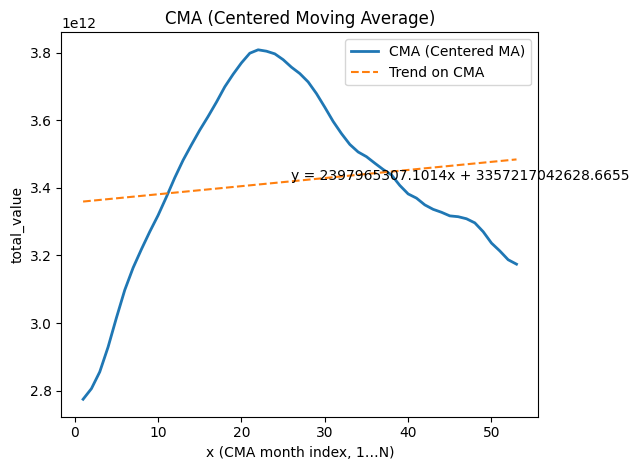

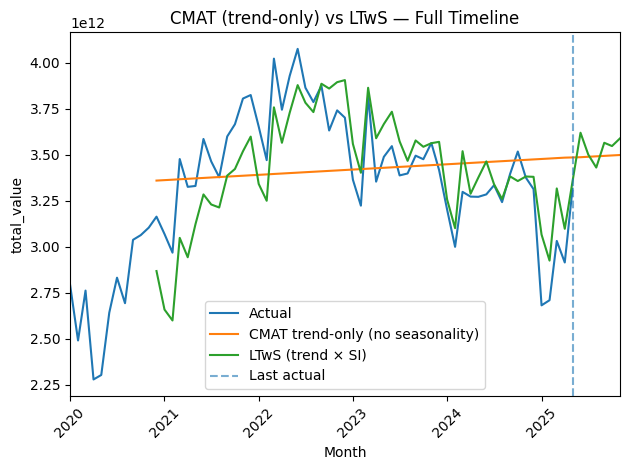

In [96]:
# --- settings ---
value_col = "total_value"   # or "total_kg"
ma_window = 12              # 12-month MA for CMA
horizon   = 6               # months ahead

# --- 1) series & CMA (centered) ---
df = monthly[["ref_date", value_col]].dropna().sort_values("ref_date")
s  = df.set_index("ref_date")[value_col].astype(float)
idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
s   = s.reindex(idx)

if ma_window % 2 == 1:
    CMA = s.rolling(ma_window, center=True).mean()
else:
    MA  = s.rolling(ma_window, center=False).mean()
    CMA = (MA + MA.shift(-1)) / 2.0

# --- 2) seasonal indices (month-of-year), normalized mean=1 ---
ratios = (s / CMA).dropna()
SI_by_m = ratios.groupby(ratios.index.month).mean().reindex(range(1,13))
SI_by_m = SI_by_m.fillna(SI_by_m.dropna().mean())
SI_norm = SI_by_m / SI_by_m.mean()

# expand SI to full index
SI = pd.Series(index=s.index, dtype=float)
for m in range(1,13):
    SI[s.index.month == m] = float(SI_norm.loc[m])

# --- 3) linear trend fit on CMA ONLY (this is CMAT's straight line) ---
mask = CMA.notna()
x = np.arange(1, mask.sum() + 1)                # 1..N, first CMA month = x=1
y = CMA[mask].values
b, a = np.polyfit(x, y, 1)                      # slope b (trend), intercept a
Trend_on_CMA = pd.Series(np.nan, index=CMA.index)
Trend_on_CMA.loc[mask.index[mask]] = a + b * x  # straight line aligned to CMA months

# --- 4) cycle factor (diagnostic, like Excel) & in-sample reseasonalized ---
Cycle = CMA / Trend_on_CMA
Y_with_seasonality_in = Trend_on_CMA * Cycle * SI   # history: Trend × Cycle × SI

# --- 5) forecasts (next h months) ---
last_date = s.index.max()
fidx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")

# future x continues the CMA index: last x = len(x)
x_future = np.arange(len(x) + 1, len(x) + 1 + horizon)

# CMAT forecast (no seasonality)
CMAT_forecast = a + b * x_future

# LTwS forecast (trend × SI, with cycle=1)
SI_future = pd.Series([float(SI_norm.loc[m]) for m in fidx.month], index=fidx)
LTwS_forecast = CMAT_forecast * SI_future.values

# --- 6) tables like Excel ---
table_hist = pd.DataFrame({
    "Actual": s,
    "CMA": CMA,
    "Trend_on_CMA": Trend_on_CMA,
    "Cycle": Cycle,
    "SI": SI,
    "Y_with_seasonality_in": Y_with_seasonality_in
})

table_future = pd.DataFrame({
    "x_index": x_future,
    "CMAT_forecast": CMAT_forecast,
    "SI_future": SI_future.values,
    "LTwS_forecast": LTwS_forecast
}, index=fidx)

display(table_hist.tail(15))
display(table_future)

print(f"Trend equation (fit on CMA): y = {b:.4f} * x + {a:.4f}")
print("Note: In-sample orange = Trend × Cycle × SI; Future sets Cycle=1, so CMAT reseasonalized == LTwS.")

# --- 7) plot CMA with its trend line & label the equation (Excel look) ---
plt.figure()
# plot only where CMA exists so it looks like your sheet
plt.plot(np.arange(1, len(x)+1), CMA[mask].values, label="CMA (Centered MA)", linewidth=2)
plt.plot(np.arange(1, len(x)+1), a + b * x, linestyle='--', label="Trend on CMA")
# place the equation in the middle
mid = len(x)//2
y_mid = a + b * (mid+1)
plt.text(mid, y_mid, f"y = {b:.4f}x + {a:.4f}", fontsize=10)
plt.title("CMA (Centered Moving Average)")
plt.xlabel("x (CMA month index, 1…N)")
plt.ylabel(value_col)
plt.legend(); plt.tight_layout(); plt.show()

# --- 8) full timeline: Actual vs CMAT (trend-only) and LTwS (trend×SI)  ---
# stitch in-sample reseasonalized (wiggly) with future LTwS
ltws_stitched = pd.concat([
    Y_with_seasonality_in.dropna().rename("CMAT reseasonalized (in-sample)"),
    pd.Series(LTwS_forecast, index=fidx, name="LTwS forecast")
]).sort_index()

# stitch straight trend (in-sample CMA trend-only) with future CMAT forecast
trend_stitched = pd.concat([
    Trend_on_CMA.dropna().rename("CMAT trend-only (in-sample)"),
    pd.Series(CMAT_forecast, index=fidx, name="CMAT trend-only (future)")
]).sort_index()

xmin, xmax = s.index.min(), fidx.max()
last_actual = s.index.max()

plt.figure()
plt.plot(s.index, s.values, label="Actual")
plt.plot(trend_stitched.index, trend_stitched.values, label="CMAT trend-only (no seasonality)")
plt.plot(ltws_stitched.index, ltws_stitched.values, label="LTwS (trend × SI)")
plt.axvline(last_actual, linestyle='--', alpha=0.6, label="Last actual")
plt.title("CMAT (trend-only) vs LTwS — Full Timeline")
plt.xlabel("Month"); plt.ylabel(value_col)
plt.xlim(xmin, xmax); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

In [97]:
# --- Diagnostics: is the forecast equal to CMA? how strong is seasonality? ---

# 1) CMA shouldn't exist in the future:
print("CMA available on future months?:", (~table_hist["CMA"].reindex(table_future.index).notna()).all())

# 2) Show seasonal indices used (Jan..Dec): min, max, range
si_vec = table_hist["SI"].dropna().groupby(table_hist.index.month).mean().reindex(range(1,13))
si_tbl = si_vec.round(3).to_frame("SI")
si_tbl["delta_from_1"] = (si_tbl["SI"] - 1.0).round(3)
print("\nSeasonal indices (mean by month):")
display(si_tbl)
print("SI min/max/range:", si_tbl["SI"].min(), si_tbl["SI"].max(), si_tbl["SI"].max() - si_tbl["SI"].min())

# 3) Compare CMAT vs LTwS in the forecast window, month by month
cmp = table_future.copy()
cmp["ratio_LTws_to_CMAT"] = cmp["LTwS_forecast"] / cmp["CMAT_forecast"]
display(cmp[["x_index","CMAT_forecast","LTwS_forecast","ratio_LTws_to_CMAT"]])


CMA available on future months?: True

Seasonal indices (mean by month):


,SI,delta_from_1
1,0.947,-0.053
2,0.910,-0.090
3,1.041,0.041
4,0.976,-0.024
5,1.008,0.008
6,1.038,0.038
7,1.003,0.003
8,0.983,-0.017
9,1.020,0.020
10,1.015,0.015


SI min/max/range: 0.91 1.041 0.1309999999999999


,x_index,CMAT_forecast,LTwS_forecast,ratio_LTws_to_CMAT
2025-06-01,54,3.486707e+12,3.619773e+12,1.038164
2025-07-01,55,3.489105e+12,3.501193e+12,1.003465
2025-08-01,56,3.491503e+12,3.430459e+12,0.982516
2025-09-01,57,3.493901e+12,3.565191e+12,1.020404
2025-10-01,58,3.496299e+12,3.547424e+12,1.014623
2025-11-01,59,3.498697e+12,3.589175e+12,1.025861


c:\Users\Predator Helios Neo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)
c:\Users\Predator Helios Neo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\2616403884.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds_reg.append(float(m.predict(X_1)))
c:\Users\Predator Helios Neo\AppData\Local\Programs\Python\Python313\Lib\site-packages\

,MAE,RMSE,MAPE%
SNaive12,2.928433e+11,3.378196e+11,8.514853
Trend+Seasonality (Reg),4.632277e+11,5.058005e+11,13.929441


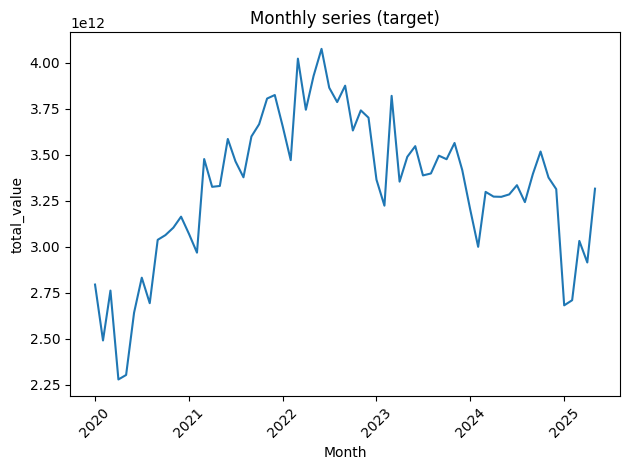

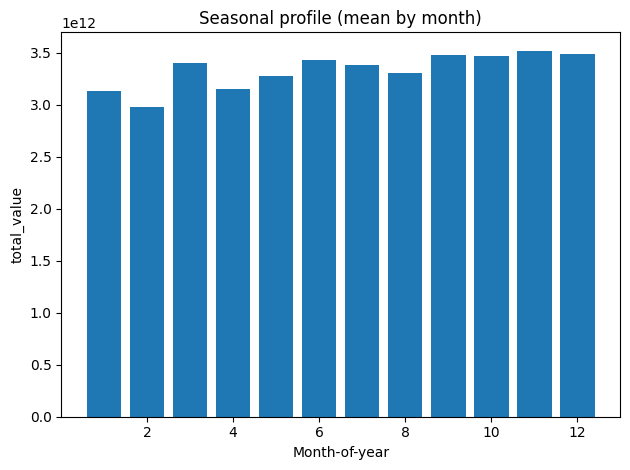

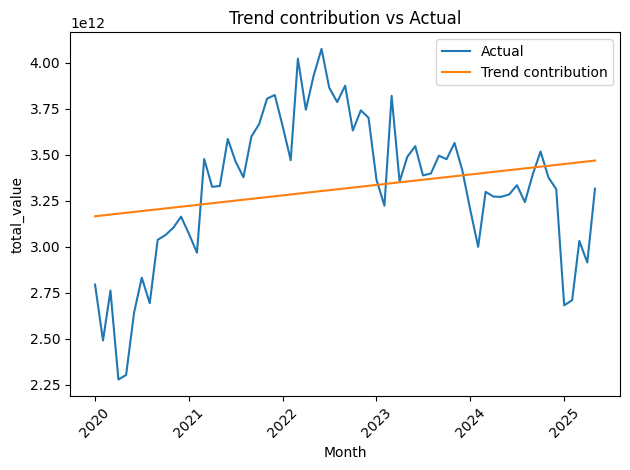

c:\Users\Predator Helios Neo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


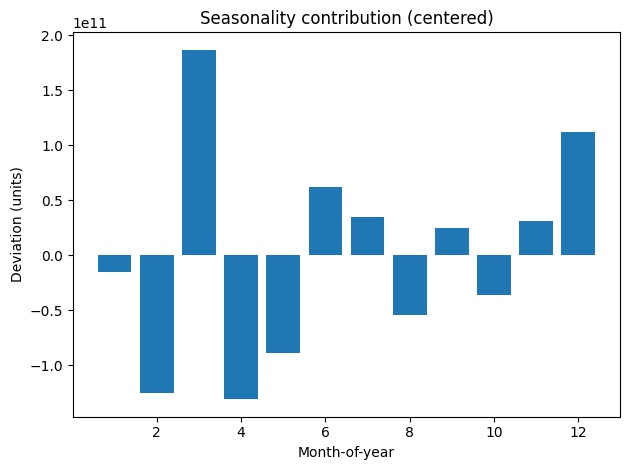

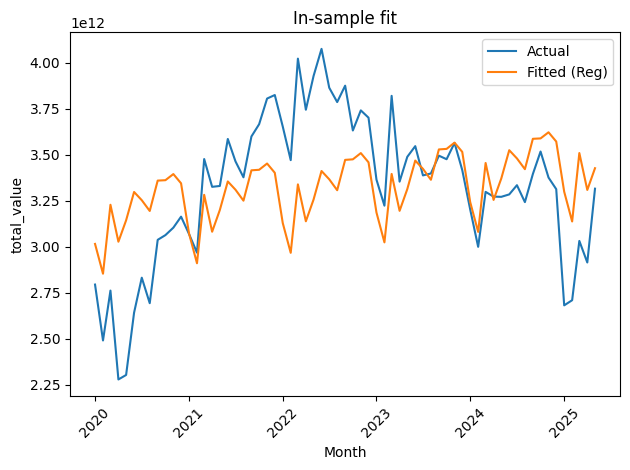

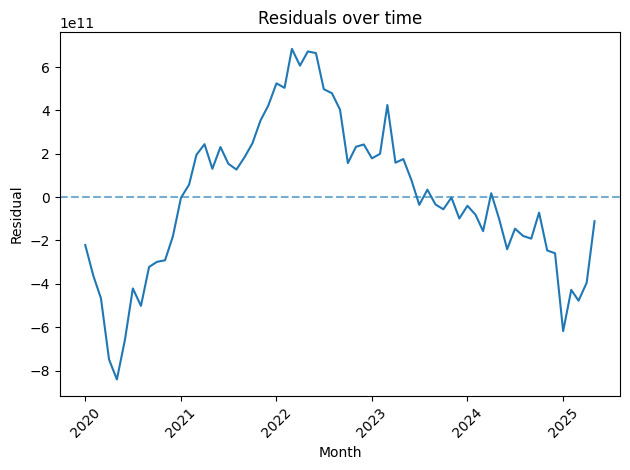

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_17784\2616403884.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(res_by_m, labels=list(range(1,13)), showmeans=True)


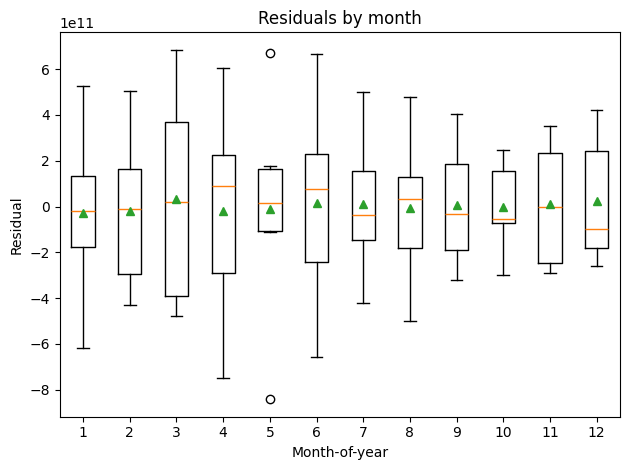

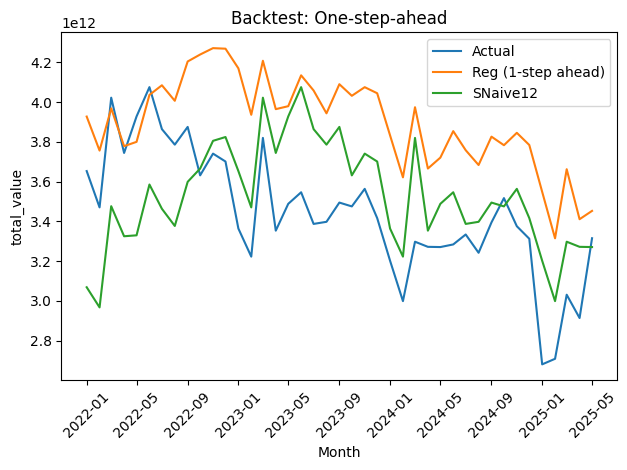

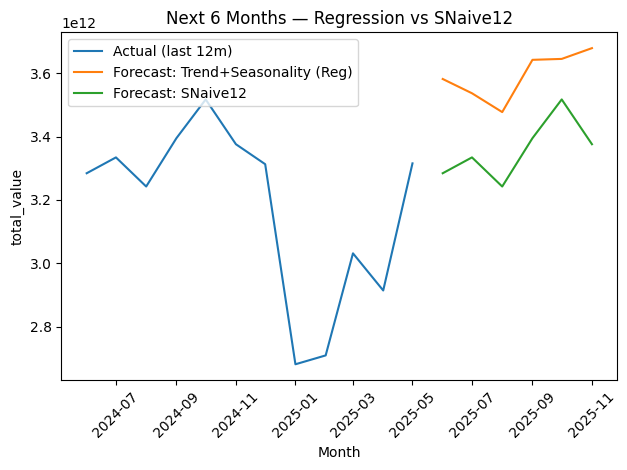

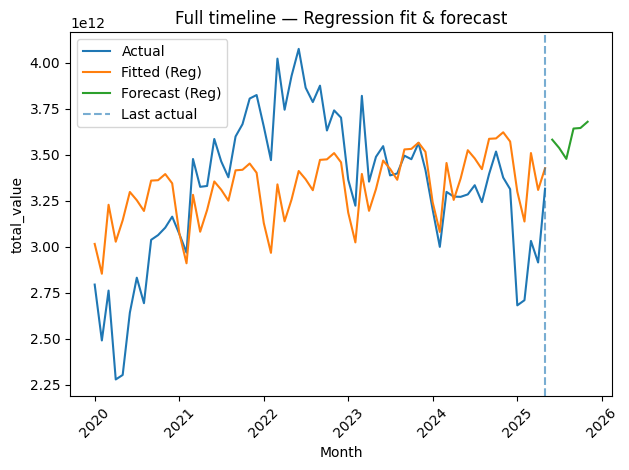

In [112]:
# -------- settings --------
value_col = "total_value"     # or "total_kg"
H         = 6                 # forecast horizon (months)
use_ridge = True              # Ridge is more stable; set False for OLS
fourier_order = 2             # 0 = none; 1-3 are typical

# -------- target series --------
y = (monthly[["ref_date", value_col]]
     .dropna().sort_values("ref_date")
     .set_index("ref_date")[value_col]
     .asfreq("MS"))

# -------- design matrix (trend + monthly seasonality + optional Fourier) --------
additional = []
if fourier_order > 0:
    additional = [CalendarFourier(freq="A", order=fourier_order)]

dp = DeterministicProcess(
    index=y.index,
    constant=True,     # intercept
    order=1,           # linear trend
    seasonal=True,     # monthly dummies
    additional_terms=additional,
    drop=True
)
X   = dp.in_sample()
X_f = dp.out_of_sample(steps=H)

Model = Ridge(alpha=1.0) if use_ridge else LinearRegression()
Model.fit(X, y)
y_fit = pd.Series(Model.predict(X), index=y.index, name="Fitted")
y_fc  = pd.Series(Model.predict(X_f), index=X_f.index, name="Forecast")

# -------- seasonal-naive(12) forecast (baseline) --------
def snaive12(series, steps):
    last12 = series.iloc[-12:]
    reps = int(np.ceil(steps/12))
    return pd.Series(np.tile(last12.values, reps)[:steps],
                     index=pd.date_range(series.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq="MS"))
y_fc_snaive = snaive12(y.dropna(), H).rename("SNaive12")

# -------- expanding-window backtest (one-step ahead) --------
def expanding_backtest(y, min_train=24):
    preds_reg, preds_sna, actuals = [], [], []
    idxs = []
    for t in range(min_train, len(y)):
        y_tr = y.iloc[:t]  # up to t-1
        dp_tr = DeterministicProcess(
            index=y_tr.index, constant=True, order=1, seasonal=True,
            additional_terms=[CalendarFourier("A", fourier_order)] if fourier_order>0 else None, drop=True
        )
        X_tr = dp_tr.in_sample()
        X_1  = dp_tr.out_of_sample(steps=1)

        m = Ridge(alpha=1.0) if use_ridge else LinearRegression()
        m.fit(X_tr, y_tr)
        preds_reg.append(float(m.predict(X_1)))

        # s-naive next step
        preds_sna.append(float(y.iloc[t-12] if t >= 12 else y_tr.iloc[-1]))

        actuals.append(float(y.iloc[t]))
        idxs.append(y.index[t])

    return (pd.Series(preds_reg, index=idxs, name="Reg(1-step)"),
            pd.Series(preds_sna, index=idxs, name="SNaive12"),
            pd.Series(actuals, index=idxs, name="Actual"))

min_train = max(24, 12)  # with more history, 24 months is reasonable
reg_bt, sna_bt, act_bt = expanding_backtest(y.dropna(), min_train=min_train)

def metrics(y_true, y_pred):
    # align by timestamp, drop NaNs
    yt, yp = pd.Series(y_true).astype(float).align(pd.Series(y_pred).astype(float), join="inner")
    yt, yp = yt.dropna(), yp.dropna()
    # MAE
    mae = mean_absolute_error(yt, yp)
    # RMSE (compute square root of MSE for compatibility with older sklearn)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    # MAPE (safe when yt has zeros)
    denom = yt.replace(0, np.nan)
    mape = (np.abs((yt - yp) / denom)).dropna().mean() * 100
    return pd.Series({"MAE": mae, "RMSE": rmse, "MAPE%": mape})

leaderboard = pd.concat([
    metrics(act_bt, reg_bt).rename("Trend+Seasonality (Reg)"),
    metrics(act_bt, sna_bt).rename("SNaive12"),
], axis=1).T.sort_values("RMSE")

display(leaderboard)

# ===================== presentation-ready charts (like the article) =====================

# 1) Raw series
plt.figure()
plt.plot(y.index, y.values)
plt.title("Monthly series (target)"); plt.xlabel("Month"); plt.ylabel(value_col)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 2) Seasonal profile (mean by month-of-year)
moy = y.groupby(y.index.month).mean()
plt.figure()
plt.bar(range(1,13), moy.values)
plt.title("Seasonal profile (mean by month)"); plt.xlabel("Month-of-year"); plt.ylabel(value_col)
plt.tight_layout(); plt.show()

# 3) Trend contribution (from the regression)
# decompose prediction into intercept + trend + seasonal(+fourier)
coef = pd.Series(Model.coef_, index=X.columns)
intercept = Model.intercept_
trend_col = [c for c in X.columns if "trend" in c or c.endswith("order 1") or c.startswith("trend")]
trend_part = intercept + (X[trend_col] @ coef[trend_col])
plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(y.index, trend_part.values, label="Trend contribution")
plt.title("Trend contribution vs Actual"); plt.xlabel("Month"); plt.ylabel(value_col)
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# 4) Seasonal contribution shape over a canonical year
# build a synthetic design for 12 months with trend held at 0 (centered)
months = pd.date_range("2000-01-01", periods=12, freq="MS")
dp_season = DeterministicProcess(
    index=months, constant=True, order=0, seasonal=True,
    additional_terms=[CalendarFourier("A", fourier_order)] if fourier_order>0 else None, drop=True
)
Xs = dp_season.in_sample()
season_cols = [c for c in Xs.columns if c not in ["const"]]  # all season-related
season_effect = Model.intercept_ + (Xs[season_cols] @ coef.reindex(season_cols).fillna(0))
season_effect = season_effect - season_effect.mean()  # center for display
plt.figure()
plt.bar(range(1,13), season_effect.values)
plt.title("Seasonality contribution (centered)"); plt.xlabel("Month-of-year"); plt.ylabel("Deviation (units)")
plt.tight_layout(); plt.show()

# 5) Fitted vs Actual (in-sample)
plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(y_fit.index, y_fit.values, label="Fitted (Reg)")
plt.title("In-sample fit"); plt.xlabel("Month"); plt.ylabel(value_col)
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# 6) Residuals diagnostics: time plot and box by month
res = (y - y_fit).dropna()
plt.figure()
plt.plot(res.index, res.values)
plt.axhline(0, linestyle="--", alpha=0.6)
plt.title("Residuals over time"); plt.xlabel("Month"); plt.ylabel("Residual")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure()
res_by_m = [res[res.index.month==m].values for m in range(1,13)]
plt.boxplot(res_by_m, labels=list(range(1,13)), showmeans=True)
plt.title("Residuals by month"); plt.xlabel("Month-of-year"); plt.ylabel("Residual")
plt.tight_layout(); plt.show()

# 7) Backtest curve (1-step ahead)
plt.figure()
plt.plot(act_bt.index, act_bt.values, label="Actual")
plt.plot(reg_bt.index, reg_bt.values, label="Reg (1-step ahead)")
plt.plot(sna_bt.index, sna_bt.values, label="SNaive12")
plt.title("Backtest: One-step-ahead")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# 8) Forecast vs last 12m
plt.figure()
plt.plot(y.tail(12).index, y.tail(12).values, label="Actual (last 12m)")
plt.plot(y_fc.index, y_fc.values, label="Forecast: Trend+Seasonality (Reg)")
plt.plot(y_fc_snaive.index, y_fc_snaive.values, label="Forecast: SNaive12")
plt.title("Next 6 Months — Regression vs SNaive12")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# 9) Full timeline (fit + forecast)
last_actual = y.index.max()
plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(y_fit.index, y_fit.values, label="Fitted (Reg)")
plt.plot(y_fc.index, y_fc.values, label="Forecast (Reg)")
plt.axvline(last_actual, linestyle="--", alpha=0.6, label="Last actual")
plt.title("Full timeline — Regression fit & forecast")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
# =================================================================================================